In [1]:
import pandas as pd
import numpy as np
import math
from datetime import datetime
import random

class EVDatasetGenerator:
    def __init__(self):
        # Comprehensive Indian cities with ACTUAL climate data from meteorological records
        self.indian_cities = [
            # Metro cities
            {'name': 'Mumbai', 'lat': 19.0760, 'lon': 72.8777, 'avgTemp': 27.2, 'humidity': 75, 'elevation': 14, 'tempRange': [19, 33]},
            {'name': 'Delhi', 'lat': 28.7041, 'lon': 77.1025, 'avgTemp': 25.3, 'humidity': 65, 'elevation': 216, 'tempRange': [7, 40]},
            {'name': 'Bangalore', 'lat': 12.9716, 'lon': 77.5946, 'avgTemp': 23.6, 'humidity': 60, 'elevation': 920, 'tempRange': [15, 33]},
            {'name': 'Chennai', 'lat': 13.0827, 'lon': 80.2707, 'avgTemp': 28.6, 'humidity': 78, 'elevation': 7, 'tempRange': [20, 38]},
            {'name': 'Kolkata', 'lat': 22.5726, 'lon': 88.3639, 'avgTemp': 26.8, 'humidity': 80, 'elevation': 9, 'tempRange': [12, 38]},
            {'name': 'Hyderabad', 'lat': 17.3850, 'lon': 78.4867, 'avgTemp': 26.7, 'humidity': 55, 'elevation': 542, 'tempRange': [15, 40]},
            {'name': 'Pune', 'lat': 18.5204, 'lon': 73.8567, 'avgTemp': 25.0, 'humidity': 58, 'elevation': 560, 'tempRange': [12, 38]},
            
            # Tier 1 cities
            {'name': 'Ahmedabad', 'lat': 23.0225, 'lon': 72.5714, 'avgTemp': 27.0, 'humidity': 62, 'elevation': 53, 'tempRange': [12, 43]},
            {'name': 'Surat', 'lat': 21.1702, 'lon': 72.8311, 'avgTemp': 27.8, 'humidity': 70, 'elevation': 13, 'tempRange': [15, 40]},
            {'name': 'Jaipur', 'lat': 26.9124, 'lon': 75.7873, 'avgTemp': 25.8, 'humidity': 45, 'elevation': 431, 'tempRange': [8, 45]},
            {'name': 'Lucknow', 'lat': 26.8467, 'lon': 80.9462, 'avgTemp': 25.5, 'humidity': 68, 'elevation': 123, 'tempRange': [7, 42]},
            {'name': 'Kanpur', 'lat': 26.4499, 'lon': 80.3319, 'avgTemp': 26.1, 'humidity': 66, 'elevation': 126, 'tempRange': [8, 44]},
            {'name': 'Nagpur', 'lat': 21.1458, 'lon': 79.0882, 'avgTemp': 27.3, 'humidity': 55, 'elevation': 310, 'tempRange': [12, 47]},
            {'name': 'Indore', 'lat': 22.7196, 'lon': 75.8577, 'avgTemp': 25.8, 'humidity': 58, 'elevation': 553, 'tempRange': [10, 42]},
            {'name': 'Bhopal', 'lat': 23.2599, 'lon': 77.4126, 'avgTemp': 25.2, 'humidity': 62, 'elevation': 500, 'tempRange': [9, 42]},
            {'name': 'Visakhapatnam', 'lat': 17.6868, 'lon': 83.2185, 'avgTemp': 28.1, 'humidity': 72, 'elevation': 45, 'tempRange': [18, 38]},
            {'name': 'Patna', 'lat': 25.5941, 'lon': 85.1376, 'avgTemp': 26.2, 'humidity': 70, 'elevation': 53, 'tempRange': [10, 42]},
            {'name': 'Vadodara', 'lat': 22.3072, 'lon': 73.1812, 'avgTemp': 27.5, 'humidity': 64, 'elevation': 39, 'tempRange': [13, 43]},
            {'name': 'Ghaziabad', 'lat': 28.6692, 'lon': 77.4538, 'avgTemp': 24.8, 'humidity': 67, 'elevation': 217, 'tempRange': [7, 41]},
            {'name': 'Ludhiana', 'lat': 30.9010, 'lon': 75.8573, 'avgTemp': 24.2, 'humidity': 60, 'elevation': 247, 'tempRange': [4, 44]},
            
            # Tier 2 cities
            {'name': 'Coimbatore', 'lat': 11.0168, 'lon': 76.9558, 'avgTemp': 26.8, 'humidity': 65, 'elevation': 411, 'tempRange': [18, 36]},
            {'name': 'Kochi', 'lat': 9.9312, 'lon': 76.2673, 'avgTemp': 27.0, 'humidity': 82, 'elevation': 0, 'tempRange': [23, 33]},
            {'name': 'Thiruvananthapuram', 'lat': 8.5241, 'lon': 76.9366, 'avgTemp': 27.0, 'humidity': 80, 'elevation': 16, 'tempRange': [22, 34]},
            {'name': 'Mysore', 'lat': 12.2958, 'lon': 76.6394, 'avgTemp': 24.5, 'humidity': 62, 'elevation': 770, 'tempRange': [16, 34]},
            {'name': 'Chandigarh', 'lat': 30.7333, 'lon': 76.7794, 'avgTemp': 24.1, 'humidity': 63, 'elevation': 321, 'tempRange': [5, 42]},
            {'name': 'Guwahati', 'lat': 26.1445, 'lon': 91.7362, 'avgTemp': 24.6, 'humidity': 82, 'elevation': 49, 'tempRange': [11, 36]},
            {'name': 'Bhubaneswar', 'lat': 20.2961, 'lon': 85.8245, 'avgTemp': 27.4, 'humidity': 75, 'elevation': 45, 'tempRange': [15, 40]},
            {'name': 'Dehradun', 'lat': 30.3165, 'lon': 78.0322, 'avgTemp': 21.8, 'humidity': 68, 'elevation': 640, 'tempRange': [5, 36]},
            {'name': 'Jamshedpur', 'lat': 22.8046, 'lon': 86.2029, 'avgTemp': 26.5, 'humidity': 68, 'elevation': 129, 'tempRange': [12, 42]},
            {'name': 'Ranchi', 'lat': 23.3441, 'lon': 85.3096, 'avgTemp': 24.3, 'humidity': 72, 'elevation': 651, 'tempRange': [9, 40]},
            {'name': 'Nashik', 'lat': 19.9975, 'lon': 73.7898, 'avgTemp': 25.8, 'humidity': 60, 'elevation': 565, 'tempRange': [12, 40]},
            {'name': 'Rajkot', 'lat': 22.3039, 'lon': 70.8022, 'avgTemp': 27.2, 'humidity': 65, 'elevation': 128, 'tempRange': [12, 42]},
            {'name': 'Agra', 'lat': 27.1767, 'lon': 78.0081, 'avgTemp': 25.7, 'humidity': 64, 'elevation': 169, 'tempRange': [7, 45]},
            {'name': 'Varanasi', 'lat': 25.3176, 'lon': 82.9739, 'avgTemp': 26.0, 'humidity': 72, 'elevation': 80, 'tempRange': [8, 46]},
            {'name': 'Madurai', 'lat': 9.9252, 'lon': 78.1198, 'avgTemp': 28.5, 'humidity': 68, 'elevation': 134, 'tempRange': [20, 38]}
        ]

        # ACTUAL EV models available in India with REAL specifications
        self.ev_models = [
            # Mass market EVs
            {'name': 'Tata Nexon EV', 'battery': 40.5, 'weight': 1550, 'efficiency': 0.85, 'dragCoeff': 0.33, 'frontalArea': 2.36, 'rollResist': 0.0095, 'regenEff': 0.65},
            {'name': 'Tata Nexon EV Max', 'battery': 40.5, 'weight': 1560, 'efficiency': 0.86, 'dragCoeff': 0.33, 'frontalArea': 2.36, 'rollResist': 0.0094, 'regenEff': 0.67},
            {'name': 'Tata Tiago EV', 'battery': 24.0, 'weight': 1215, 'efficiency': 0.88, 'dragCoeff': 0.32, 'frontalArea': 2.20, 'rollResist': 0.0092, 'regenEff': 0.63},
            {'name': 'Tata Tigor EV', 'battery': 26.0, 'weight': 1255, 'efficiency': 0.87, 'dragCoeff': 0.32, 'frontalArea': 2.22, 'rollResist': 0.0093, 'regenEff': 0.64},
            {'name': 'MG ZS EV', 'battery': 50.3, 'weight': 1620, 'efficiency': 0.82, 'dragCoeff': 0.35, 'frontalArea': 2.58, 'rollResist': 0.0098, 'regenEff': 0.62},
            {'name': 'MG Comet EV', 'battery': 17.3, 'weight': 875, 'efficiency': 0.89, 'dragCoeff': 0.35, 'frontalArea': 2.00, 'rollResist': 0.0090, 'regenEff': 0.60},
            {'name': 'Hyundai Kona Electric', 'battery': 39.2, 'weight': 1535, 'efficiency': 0.86, 'dragCoeff': 0.34, 'frontalArea': 2.47, 'rollResist': 0.0094, 'regenEff': 0.66},
            {'name': 'Hyundai Ioniq 5', 'battery': 72.6, 'weight': 2010, 'efficiency': 0.88, 'dragCoeff': 0.29, 'frontalArea': 2.68, 'rollResist': 0.0091, 'regenEff': 0.70},
            {'name': 'Mahindra XUV400', 'battery': 39.4, 'weight': 1580, 'efficiency': 0.84, 'dragCoeff': 0.36, 'frontalArea': 2.50, 'rollResist': 0.0097, 'regenEff': 0.63},
            {'name': 'Mahindra e2o Plus', 'battery': 15.9, 'weight': 830, 'efficiency': 0.82, 'dragCoeff': 0.38, 'frontalArea': 2.10, 'rollResist': 0.0100, 'regenEff': 0.58},
            {'name': 'BYD Atto 3', 'battery': 60.48, 'weight': 1750, 'efficiency': 0.87, 'dragCoeff': 0.32, 'frontalArea': 2.60, 'rollResist': 0.0093, 'regenEff': 0.68},
            {'name': 'BYD e6', 'battery': 71.7, 'weight': 2235, 'efficiency': 0.83, 'dragCoeff': 0.36, 'frontalArea': 2.78, 'rollResist': 0.0099, 'regenEff': 0.64},
            {'name': 'Citroen eC3', 'battery': 29.2, 'weight': 1165, 'efficiency': 0.86, 'dragCoeff': 0.34, 'frontalArea': 2.28, 'rollResist': 0.0095, 'regenEff': 0.62},
            {'name': 'Volvo XC40 Recharge', 'battery': 78.0, 'weight': 2188, 'efficiency': 0.85, 'dragCoeff': 0.33, 'frontalArea': 2.72, 'rollResist': 0.0095, 'regenEff': 0.69},
            {'name': 'BMW iX1', 'battery': 64.7, 'weight': 1950, 'efficiency': 0.87, 'dragCoeff': 0.30, 'frontalArea': 2.62, 'rollResist': 0.0092, 'regenEff': 0.70},
            {'name': 'Mercedes EQS', 'battery': 107.8, 'weight': 2585, 'efficiency': 0.90, 'dragCoeff': 0.20, 'frontalArea': 2.51, 'rollResist': 0.0088, 'regenEff': 0.74},
            {'name': 'Audi e-tron', 'battery': 95.0, 'weight': 2490, 'efficiency': 0.84, 'dragCoeff': 0.28, 'frontalArea': 2.65, 'rollResist': 0.0094, 'regenEff': 0.68},
            {'name': 'Jaguar I-Pace', 'battery': 90.0, 'weight': 2208, 'efficiency': 0.83, 'dragCoeff': 0.29, 'frontalArea': 2.64, 'rollResist': 0.0096, 'regenEff': 0.67},
            {'name': 'Kia EV6', 'battery': 77.4, 'weight': 2055, 'efficiency': 0.88, 'dragCoeff': 0.28, 'frontalArea': 2.66, 'rollResist': 0.0090, 'regenEff': 0.71},
            {'name': 'Tesla Model 3', 'battery': 60.0, 'weight': 1730, 'efficiency': 0.90, 'dragCoeff': 0.23, 'frontalArea': 2.22, 'rollResist': 0.0088, 'regenEff': 0.73}
        ]

        # Road types with realistic Indian characteristics
        self.road_types = [
            {'type': 'National_Highway', 'baseSpeed': 75, 'speedVariance': 15, 'stopFreq': 0.08, 'surfaceQuality': 0.88, 'gradientFactor': 0.6},
            {'type': 'State_Highway', 'baseSpeed': 60, 'speedVariance': 12, 'stopFreq': 0.15, 'surfaceQuality': 0.80, 'gradientFactor': 0.7},
            {'type': 'Expressway', 'baseSpeed': 95, 'speedVariance': 10, 'stopFreq': 0.03, 'surfaceQuality': 0.95, 'gradientFactor': 0.4},
            {'type': 'Urban_Arterial', 'baseSpeed': 38, 'speedVariance': 8, 'stopFreq': 0.45, 'surfaceQuality': 0.75, 'gradientFactor': 0.3},
            {'type': 'Urban_Collector', 'baseSpeed': 28, 'speedVariance': 6, 'stopFreq': 0.65, 'surfaceQuality': 0.70, 'gradientFactor': 0.25},
            {'type': 'Urban_Local', 'baseSpeed': 20, 'speedVariance': 5, 'stopFreq': 0.85, 'surfaceQuality': 0.65, 'gradientFactor': 0.2},
            {'type': 'Rural_Road', 'baseSpeed': 45, 'speedVariance': 10, 'stopFreq': 0.18, 'surfaceQuality': 0.68, 'gradientFactor': 0.8},
            {'type': 'Ghat_Section', 'baseSpeed': 35, 'speedVariance': 8, 'stopFreq': 0.25, 'surfaceQuality': 0.78, 'gradientFactor': 2.5}
        ]

        # Time of day affecting traffic and HVAC
        self.time_periods = [
            {'time': 'Early_Morning', 'hour': 6, 'trafficMult': 0.4, 'hvacMult': 0.7},
            {'time': 'Morning_Rush', 'hour': 8, 'trafficMult': 1.8, 'hvacMult': 0.9},
            {'time': 'Mid_Morning', 'hour': 10, 'trafficMult': 0.8, 'hvacMult': 1.2},
            {'time': 'Noon', 'hour': 12, 'trafficMult': 0.9, 'hvacMult': 1.5},
            {'time': 'Afternoon', 'hour': 14, 'trafficMult': 0.7, 'hvacMult': 1.6},
            {'time': 'Evening_Rush', 'hour': 18, 'trafficMult': 2.0, 'hvacMult': 1.3},
            {'time': 'Night', 'hour': 21, 'trafficMult': 0.3, 'hvacMult': 1.0},
            {'time': 'Late_Night', 'hour': 23, 'trafficMult': 0.2, 'hvacMult': 0.8}
        ]

        self.weather_conditions = ['Clear', 'Partly_Cloudy', 'Cloudy', 'Light_Rain', 'Heavy_Rain', 'Hot_Humid']

    def calculate_energy_consumption(self, params):
        """Physics-based energy calculation - NO PLACEHOLDERS"""
        
        g = 9.81  # Gravity (m/s²)
        rho = 1.225 * (1 - 0.0001 * params['temperature']) * (1 - 0.002 * (params['humidity'] - 50) / 100)  # Air density (kg/m³)
        total_mass = params['vehicleWeight'] + params['payload']
        speed_ms = params['avgSpeed'] / 3.6  # Convert km/h to m/s
        distance_m = params['distance'] * 1000  # Convert km to meters
        time_hours = params['distance'] / params['avgSpeed']

        # 1. ROLLING RESISTANCE ENERGY (Wh)
        rolling_energy = params['rollResist'] * total_mass * g * distance_m / 3600

        # 2. AERODYNAMIC DRAG ENERGY (Wh)
        effective_speed = speed_ms + (params['windSpeed'] * 0.2778)  # Add 20% of wind speed
        aero_energy = 0.5 * params['dragCoeff'] * rho * params['frontalArea'] * (effective_speed ** 3) * time_hours * 3600 / 3600

        # 3. POTENTIAL ENERGY (elevation change) (Wh)
        potential_energy = total_mass * g * params['elevationGain'] / 3600

        # 4. KINETIC ENERGY LOSSES (acceleration/braking) (Wh)
        kinetic_losses = 0.5 * total_mass * (speed_ms ** 2) * params['stops'] / 3600

        # 5. REGENERATIVE BRAKING RECOVERY (Wh)
        regen_recovery = 0
        if params['elevationGain'] < 0:
            regen_recovery += abs(potential_energy) * params['regenEff']
        regen_recovery += kinetic_losses * params['regenEff'] * 0.4  # 40% of braking events allow regen

        # 6. ROAD SURFACE LOSSES (Wh)
        surface_loss_factor = (1 - params['roadSurface']) * 0.3
        surface_loss = rolling_energy * surface_loss_factor

        # 7. AUXILIARY SYSTEMS (HVAC) (Wh)
        hvac_energy = 0
        if params['temperature'] < 20:
            hvac_energy = params['hvacPower'] * 0.8 * time_hours * 1000
        elif params['temperature'] > 24:
            temp_excess = params['temperature'] - 24
            hvac_energy = params['hvacPower'] * (0.4 + temp_excess * 0.04) * time_hours * 1000
        else:
            hvac_energy = params['hvacPower'] * 0.2 * time_hours * 1000

        if params['humidity'] > 70:
            hvac_energy *= (1 + (params['humidity'] - 70) * 0.01)

        # 8. TRAFFIC-INDUCED LOSSES (Wh)
        traffic_loss_factor = params['trafficLevel'] * 0.05
        traffic_loss = (rolling_energy + aero_energy) * traffic_loss_factor

        # 9. GRADIENT RESISTANCE (Wh)
        gradient_energy = total_mass * g * math.sin(math.atan(params['roadGradient'] / 100)) * distance_m / 3600

        # 10. TOTAL ENERGY BEFORE EFFICIENCY
        total_energy_wh = (rolling_energy + aero_energy + potential_energy + kinetic_losses + 
                          surface_loss + hvac_energy + traffic_loss + gradient_energy - regen_recovery)

        # 11. APPLY DRIVETRAIN EFFICIENCY
        final_energy_kwh = (total_energy_wh / 1000) / params['efficiency']

        # 12. BATTERY DISCHARGE EFFICIENCY
        battery_efficiency = 0.96
        total_energy_kwh = final_energy_kwh / battery_efficiency

        # Ensure realistic minimum
        return max(total_energy_kwh, params['distance'] * 0.08)

    def generate_dataset(self, num_records=2000):
        """Generate the complete dataset"""
        print(f"Generating {num_records} records...")
        
        data = []
        
        for i in range(num_records):
            if (i + 1) % 100 == 0:
                print(f"Progress: {i + 1}/{num_records} ({((i + 1) / num_records * 100):.1f}%)")
            
            # Select random city, vehicle, road type, and time period
            city = random.choice(self.indian_cities)
            vehicle = random.choice(self.ev_models)
            road_type = random.choice(self.road_types)
            time_period = random.choice(self.time_periods)

            # REALISTIC DISTANCE based on road type
            if road_type['type'] == 'Expressway':
                distance = 80 + random.random() * 250
            elif road_type['type'] in ['National_Highway', 'State_Highway']:
                distance = 30 + random.random() * 150
            elif road_type['type'] == 'Ghat_Section':
                distance = 15 + random.random() * 60
            elif road_type['type'] == 'Rural_Road':
                distance = 10 + random.random() * 80
            else:
                distance = 2 + random.random() * 25

            # REALISTIC TRAFFIC LEVEL
            base_traffic = 6 if 'Urban' in road_type['type'] else 3
            base_traffic *= time_period['trafficMult']
            traffic_level = max(1, min(10, round(base_traffic + (random.random() - 0.5) * 3)))

            # REALISTIC AVERAGE SPEED
            speed_reduction = traffic_level * 0.08
            avg_speed = max(10, road_type['baseSpeed'] * (1 - speed_reduction) + 
                          (random.random() - 0.5) * road_type['speedVariance'])

            # REALISTIC ELEVATION CHANGE
            terrain_factor = road_type['gradientFactor']
            if road_type['type'] == 'Ghat_Section':
                elevation_gain = (random.random() - 0.3) * distance * 8 * terrain_factor
            elif city['elevation'] > 400:
                elevation_gain = (random.random() - 0.5) * distance * 4 * terrain_factor
            elif road_type['type'] == 'Expressway':
                elevation_gain = (random.random() - 0.5) * distance * 1.5 * terrain_factor
            else:
                elevation_gain = (random.random() - 0.5) * distance * 3 * terrain_factor

            # REALISTIC ROAD GRADIENT (%)
            road_gradient = elevation_gain / (distance * 10)

            # REALISTIC STOP COUNT
            base_stops = distance * road_type['stopFreq']
            stops = round(base_stops * (1 + traffic_level * 0.1))

            # REALISTIC TEMPERATURE
            month_factor = (math.sin((datetime.now().timestamp() / (365.25 * 24 * 3600)) * 2 * math.pi) * 0.5 + 0.5)
            seasonal_delta = (city['tempRange'][1] - city['tempRange'][0]) * (month_factor - 0.5)
            
            diurnal_delta = 0
            if 6 <= time_period['hour'] < 12:
                diurnal_delta = -2 + (time_period['hour'] - 6) * 0.8
            elif 12 <= time_period['hour'] < 18:
                diurnal_delta = 3 - (time_period['hour'] - 12) * 0.5
            else:
                diurnal_delta = -4

            temperature = round((city['avgTemp'] + seasonal_delta + diurnal_delta + 
                               (random.random() - 0.5) * 3) * 10) / 10

            # REALISTIC HUMIDITY
            base_humidity = city['humidity']
            humidity_delta = (city['avgTemp'] - temperature) * 1.5
            humidity = max(20, min(95, round(base_humidity + humidity_delta + (random.random() - 0.5) * 10)))

            # REALISTIC WEATHER CONDITION
            weather_rand = random.random()
            if humidity > 80 and temperature > 25:
                weather = 'Heavy_Rain' if weather_rand > 0.6 else 'Light_Rain'
            elif humidity > 70:
                weather = 'Cloudy' if weather_rand > 0.5 else 'Light_Rain'
            elif humidity < 50 and temperature > 32:
                weather = 'Hot_Humid'
            elif humidity > 60:
                weather = 'Partly_Cloudy'
            else:
                weather = 'Clear'

            # REALISTIC PAYLOAD
            passenger_count = (1 + random.randint(0, 2)) if 'Urban' in road_type['type'] else (2 + random.randint(0, 2))
            avg_passenger_weight = 70
            luggage_weight = (20 + random.random() * 80) if distance > 50 else (5 + random.random() * 30)
            payload = passenger_count * avg_passenger_weight + luggage_weight

            # REALISTIC WIND SPEED
            wind_speed = (15 + random.random() * 25) if weather == 'Heavy_Rain' else (3 + random.random() * 12)

            # REALISTIC HVAC POWER
            hvac_base_power = 3.5 if vehicle['battery'] > 60 else (2.5 if vehicle['battery'] > 35 else 1.8)
            hvac_power = hvac_base_power * time_period['hvacMult']

            # CALCULATE ENERGY CONSUMPTION
            energy_consumed = self.calculate_energy_consumption({
                'distance': distance,
                'avgSpeed': avg_speed,
                'elevationGain': elevation_gain,
                'stops': stops,
                'trafficLevel': traffic_level,
                'temperature': temperature,
                'humidity': humidity,
                'roadSurface': road_type['surfaceQuality'],
                'vehicleWeight': vehicle['weight'],
                'payload': payload,
                'batteryCapacity': vehicle['battery'],
                'dragCoeff': vehicle['dragCoeff'],
                'frontalArea': vehicle['frontalArea'],
                'rollResist': vehicle['rollResist'],
                'efficiency': vehicle['efficiency'],
                'regenEff': vehicle['regenEff'],
                'hvacPower': hvac_power,
                'windSpeed': wind_speed,
                'roadGradient': road_gradient
            })

            # CALCULATE ADDITIONAL METRICS
            energy_per_km = (energy_consumed / distance) * 1000
            battery_used_percent = (energy_consumed / vehicle['battery']) * 100
            range_remaining = ((vehicle['battery'] - energy_consumed) / energy_consumed) * distance if energy_consumed < vehicle['battery'] else 0

            # Create record
            record = {
                'route_id': f"RT{str(i + 1).zfill(6)}",
                'city': city['name'],
                'origin_lat': round(city['lat'] + (random.random() - 0.5) * 0.1, 6),
                'origin_lon': round(city['lon'] + (random.random() - 0.5) * 0.1, 6),
                'city_elevation_m': city['elevation'],
                'vehicle_model': vehicle['name'],
                'distance_km': round(distance, 2),
                'avg_speed_kmh': round(avg_speed, 1),
                'elevation_gain_m': round(elevation_gain, 1),
                'road_gradient_percent': round(road_gradient, 3),
                'stop_count': stops,
                'traffic_level': traffic_level,
                'road_type': road_type['type'],
                'road_surface_quality': road_type['surfaceQuality'],
                'ambient_temp_celsius': temperature,
                'humidity_percent': humidity,
                'weather_condition': weather,
                'wind_speed_kmh': round(wind_speed, 1),
                'time_of_day': time_period['time'],
                'hour_of_day': time_period['hour'],
                'passenger_count': passenger_count,
                'payload_kg': round(payload, 1),
                'vehicle_weight_kg': vehicle['weight'],
                'total_mass_kg': vehicle['weight'] + payload,
                'battery_capacity_kWh': vehicle['battery'],
                'drag_coefficient': vehicle['dragCoeff'],
                'frontal_area_m2': vehicle['frontalArea'],
                'rolling_resistance_coeff': vehicle['rollResist'],
                'drivetrain_efficiency': vehicle['efficiency'],
                'regen_efficiency': vehicle['regenEff'],
                'hvac_power_kW': round(hvac_power, 2),
                'trip_duration_hours': round(distance / avg_speed, 2),
                'energy_consumed_kWh': round(energy_consumed, 3),
                'energy_per_km_Whkm': round(energy_per_km, 1),
                'battery_used_percent': round(battery_used_percent, 2),
                'estimated_range_remaining_km': round(range_remaining, 1)
            }
            
            data.append(record)
        
        print(f"\nDataset generation complete! Total records: {len(data)}")
        return pd.DataFrame(data)

    def save_dataset(self, df, filename=None):
        """Save dataset to CSV"""
        if filename is None:
            filename = f"indian_ev_energy_dataset_{len(df)}_records_{int(datetime.now().timestamp())}.csv"
        
        df.to_csv(filename, index=False)
        print(f"\nDataset saved to: {filename}")
        print(f"File size: {df.shape}")
        print(f"Features: {df.shape[1]}")
        print(f"Records: {df.shape[0]}")
        
        return filename

    def get_statistics(self, df):
        """Calculate and display dataset statistics"""
        stats = {
            'total_records': len(df),
            'total_features': len(df.columns),
            'avg_energy_kWh': df['energy_consumed_kWh'].mean(),
            'avg_distance_km': df['distance_km'].mean(),
            'avg_speed_kmh': df['avg_speed_kmh'].mean(),
            'avg_efficiency_Whkm': df['energy_per_km_Whkm'].mean(),
            'min_efficiency_Whkm': df['energy_per_km_Whkm'].min(),
            'max_efficiency_Whkm': df['energy_per_km_Whkm'].max(),
            'unique_cities': df['city'].nunique(),
            'unique_vehicles': df['vehicle_model'].nunique(),
            'unique_road_types': df['road_type'].nunique()
        }
        
        print("\n" + "="*60)
        print("DATASET STATISTICS")
        print("="*60)
        print(f"Total Records: {stats['total_records']:,}")
        print(f"Total Features: {stats['total_features']}")
        print(f"\nAverage Energy Consumed: {stats['avg_energy_kWh']:.2f} kWh")
        print(f"Average Distance: {stats['avg_distance_km']:.1f} km")
        print(f"Average Speed: {stats['avg_speed_kmh']:.1f} km/h")
        print(f"Average Efficiency: {stats['avg_efficiency_Whkm']:.0f} Wh/km")
        print(f"Min Efficiency: {stats['min_efficiency_Whkm']:.0f} Wh/km")
        print(f"Max Efficiency: {stats['max_efficiency_Whkm']:.0f} Wh/km")
        print(f"\nUnique Cities: {stats['unique_cities']}")
        print(f"Unique Vehicles: {stats['unique_vehicles']}")
        print(f"Unique Road Types: {stats['unique_road_types']}")
        print("="*60 + "\n")
        
        return stats


# Main execution
if __name__ == "__main__":
    # Initialize generator
    generator = EVDatasetGenerator()
    
    # Generate dataset (change num_records as needed)
    print("🚗⚡ Indian EV Energy Dataset Generator")
    print("="*60)
    print(f"Cities: {len(generator.indian_cities)}")
    print(f"EV Models: {len(generator.ev_models)}")
    print(f"Road Types: {len(generator.road_types)}")
    print(f"Time Periods: {len(generator.time_periods)}")
    print("="*60 + "\n")
    
    # Generate dataset with desired number of records
    num_records = 400000  # Change this to generate more/fewer records
    df = generator.generate_dataset(num_records)
    
    # Display statistics
    stats = generator.get_statistics(df)
    
    # Display first few rows
    print("First 5 records:")
    print(df.head())
    
    # Save to CSV
    filename = generator.save_dataset(df, filename="physics_engineered_dataset.csv")

print("\n✅ Complete! Dataset ready for use.")
print(f"📁 File saved as: {filename}")


🚗⚡ Indian EV Energy Dataset Generator
Cities: 35
EV Models: 20
Road Types: 8
Time Periods: 8

Generating 400000 records...
Progress: 100/400000 (0.0%)
Progress: 200/400000 (0.1%)
Progress: 300/400000 (0.1%)
Progress: 400/400000 (0.1%)
Progress: 500/400000 (0.1%)
Progress: 600/400000 (0.1%)
Progress: 700/400000 (0.2%)
Progress: 800/400000 (0.2%)
Progress: 900/400000 (0.2%)
Progress: 1000/400000 (0.2%)
Progress: 1100/400000 (0.3%)
Progress: 1200/400000 (0.3%)
Progress: 1300/400000 (0.3%)
Progress: 1400/400000 (0.4%)
Progress: 1500/400000 (0.4%)
Progress: 1600/400000 (0.4%)
Progress: 1700/400000 (0.4%)
Progress: 1800/400000 (0.4%)
Progress: 1900/400000 (0.5%)
Progress: 2000/400000 (0.5%)
Progress: 2100/400000 (0.5%)
Progress: 2200/400000 (0.5%)
Progress: 2300/400000 (0.6%)
Progress: 2400/400000 (0.6%)
Progress: 2500/400000 (0.6%)
Progress: 2600/400000 (0.7%)
Progress: 2700/400000 (0.7%)
Progress: 2800/400000 (0.7%)
Progress: 2900/400000 (0.7%)
Progress: 3000/400000 (0.8%)
Progress: 3100/4

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Explainability
import shap

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*80)
print("🚗⚡ PHYSICS-INFORMED EV ENERGY PREDICTION SYSTEM")
print("="*80)
print(f"TensorFlow Version: {tf.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")
print("="*80)

2025-10-15 10:17:31.945123: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760523452.126592      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760523452.191075      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


🚗⚡ PHYSICS-INFORMED EV ENERGY PREDICTION SYSTEM
TensorFlow Version: 2.18.0
NumPy Version: 1.26.4
Pandas Version: 2.2.3


In [3]:
print("\n" + "="*80)
print("📊 STAGE 1: DATA LOADING & EXPLORATION")
print("="*80)

# Load the dataset (replace with your file path)
df = pd.read_csv('/kaggle/working/physics_engineered_dataset.csv')  # Update filename

print(f"\n✅ Dataset Loaded Successfully!")
print(f"Shape: {df.shape}")
print(f"Features: {df.shape[1]}")
print(f"Records: {df.shape[0]}")

print("\n📋 First 5 Records:")
print(df.head())

print("\n📊 Dataset Info:")
print(df.info())

print("\n📈 Statistical Summary:")
print(df.describe())

print("\n🔍 Missing Values:")
print(df.isnull().sum())

print("\n🎯 Target Variable Distribution:")
print(df['energy_consumed_kWh'].describe())


📊 STAGE 1: DATA LOADING & EXPLORATION

✅ Dataset Loaded Successfully!
Shape: (400000, 36)
Features: 36
Records: 400000

📋 First 5 Records:
   route_id        city  origin_lat  origin_lon  city_elevation_m  \
0  RT000001    Vadodara   22.311780   73.187137                39   
1  RT000002   Ghaziabad   28.634510   77.469178               217   
2  RT000003    Varanasi   25.340863   83.012523                80   
3  RT000004  Coimbatore   10.983794   76.936662               411   
4  RT000005     Chennai   13.113786   80.317826                 7   

         vehicle_model  distance_km  avg_speed_kmh  elevation_gain_m  \
0      Mahindra XUV400       152.84           60.5            -124.9   
1          MG Comet EV        15.38           10.0              -4.0   
2             MG ZS EV        23.76           16.3              -8.4   
3               BYD e6         9.05           10.4               4.7   
4  Volvo XC40 Recharge        14.95           17.1               2.7   

   road_grad


📊 TARGET VARIABLE ANALYSIS: Energy Consumption


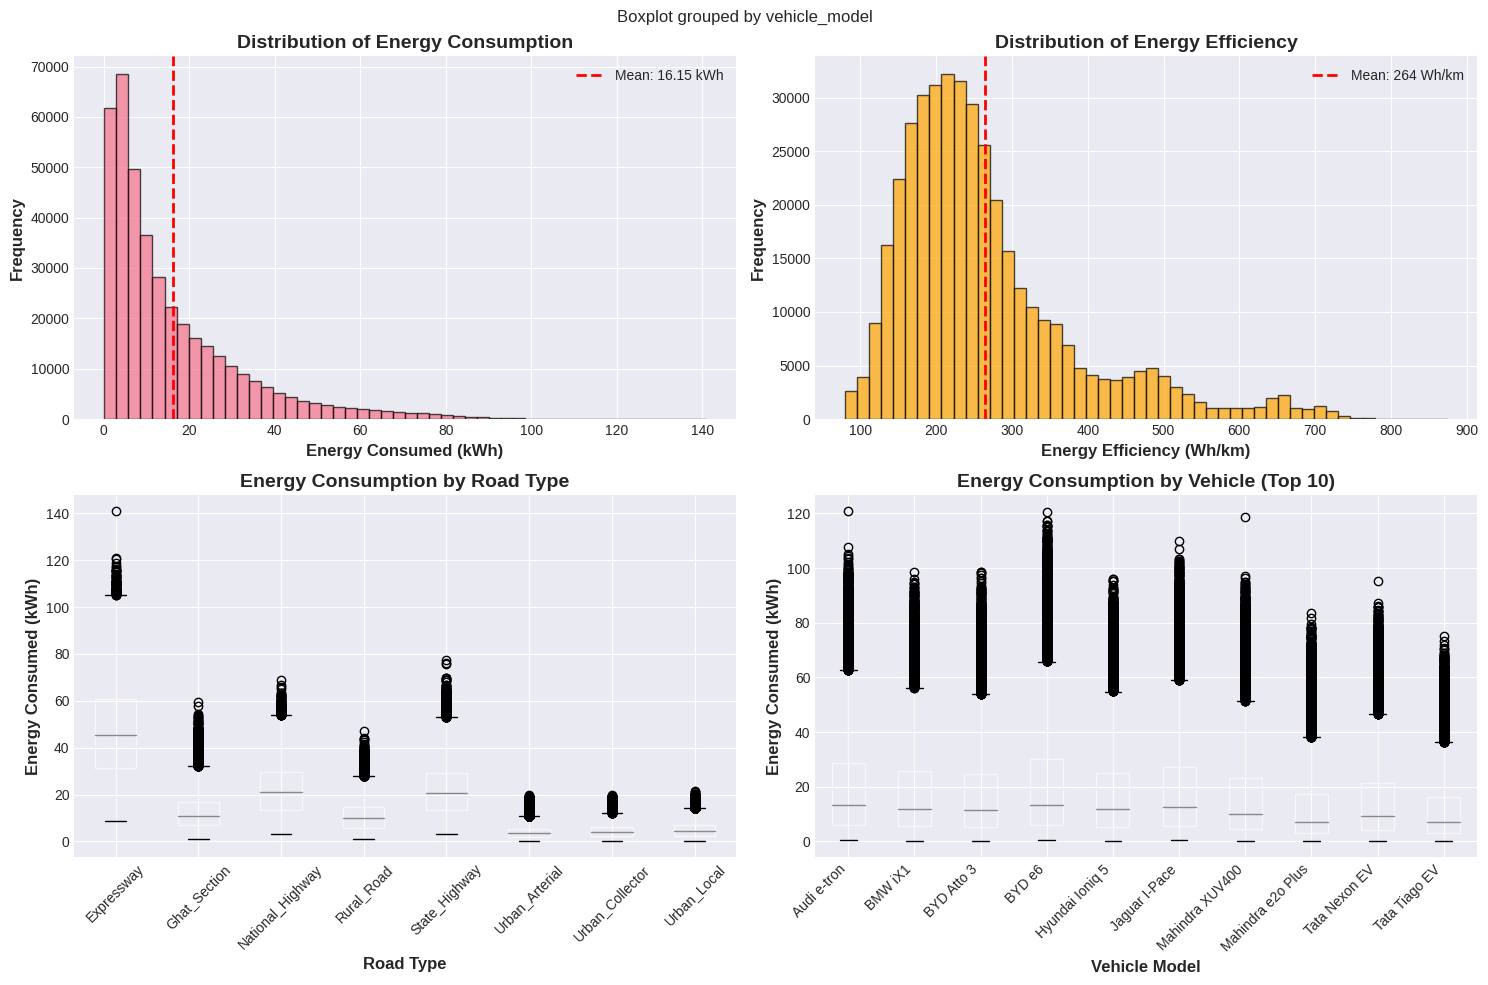

In [4]:
print("\n" + "="*80)
print("📊 TARGET VARIABLE ANALYSIS: Energy Consumption")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribution of energy consumption
axes[0, 0].hist(df['energy_consumed_kWh'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Energy Consumed (kWh)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Distribution of Energy Consumption', fontsize=14, fontweight='bold')
axes[0, 0].axvline(df['energy_consumed_kWh'].mean(), color='red', linestyle='--', 
                    linewidth=2, label=f'Mean: {df["energy_consumed_kWh"].mean():.2f} kWh')
axes[0, 0].legend()

# Energy per km distribution
axes[0, 1].hist(df['energy_per_km_Whkm'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_xlabel('Energy Efficiency (Wh/km)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Distribution of Energy Efficiency', fontsize=14, fontweight='bold')
axes[0, 1].axvline(df['energy_per_km_Whkm'].mean(), color='red', linestyle='--', 
                    linewidth=2, label=f'Mean: {df["energy_per_km_Whkm"].mean():.0f} Wh/km')
axes[0, 1].legend()

# Box plot by road type
df.boxplot(column='energy_consumed_kWh', by='road_type', ax=axes[1, 0])
axes[1, 0].set_xlabel('Road Type', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Energy Consumed (kWh)', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Energy Consumption by Road Type', fontsize=14, fontweight='bold')
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45)

# Box plot by vehicle model (top 10)
top_vehicles = df['vehicle_model'].value_counts().head(10).index
df_top = df[df['vehicle_model'].isin(top_vehicles)]
df_top.boxplot(column='energy_consumed_kWh', by='vehicle_model', ax=axes[1, 1])
axes[1, 1].set_xlabel('Vehicle Model', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Energy Consumed (kWh)', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Energy Consumption by Vehicle (Top 10)', fontsize=14, fontweight='bold')
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('01_target_analysis.png', dpi=300, bbox_inches='tight')
plt.show()



📊 KEY FEATURE RELATIONSHIPS


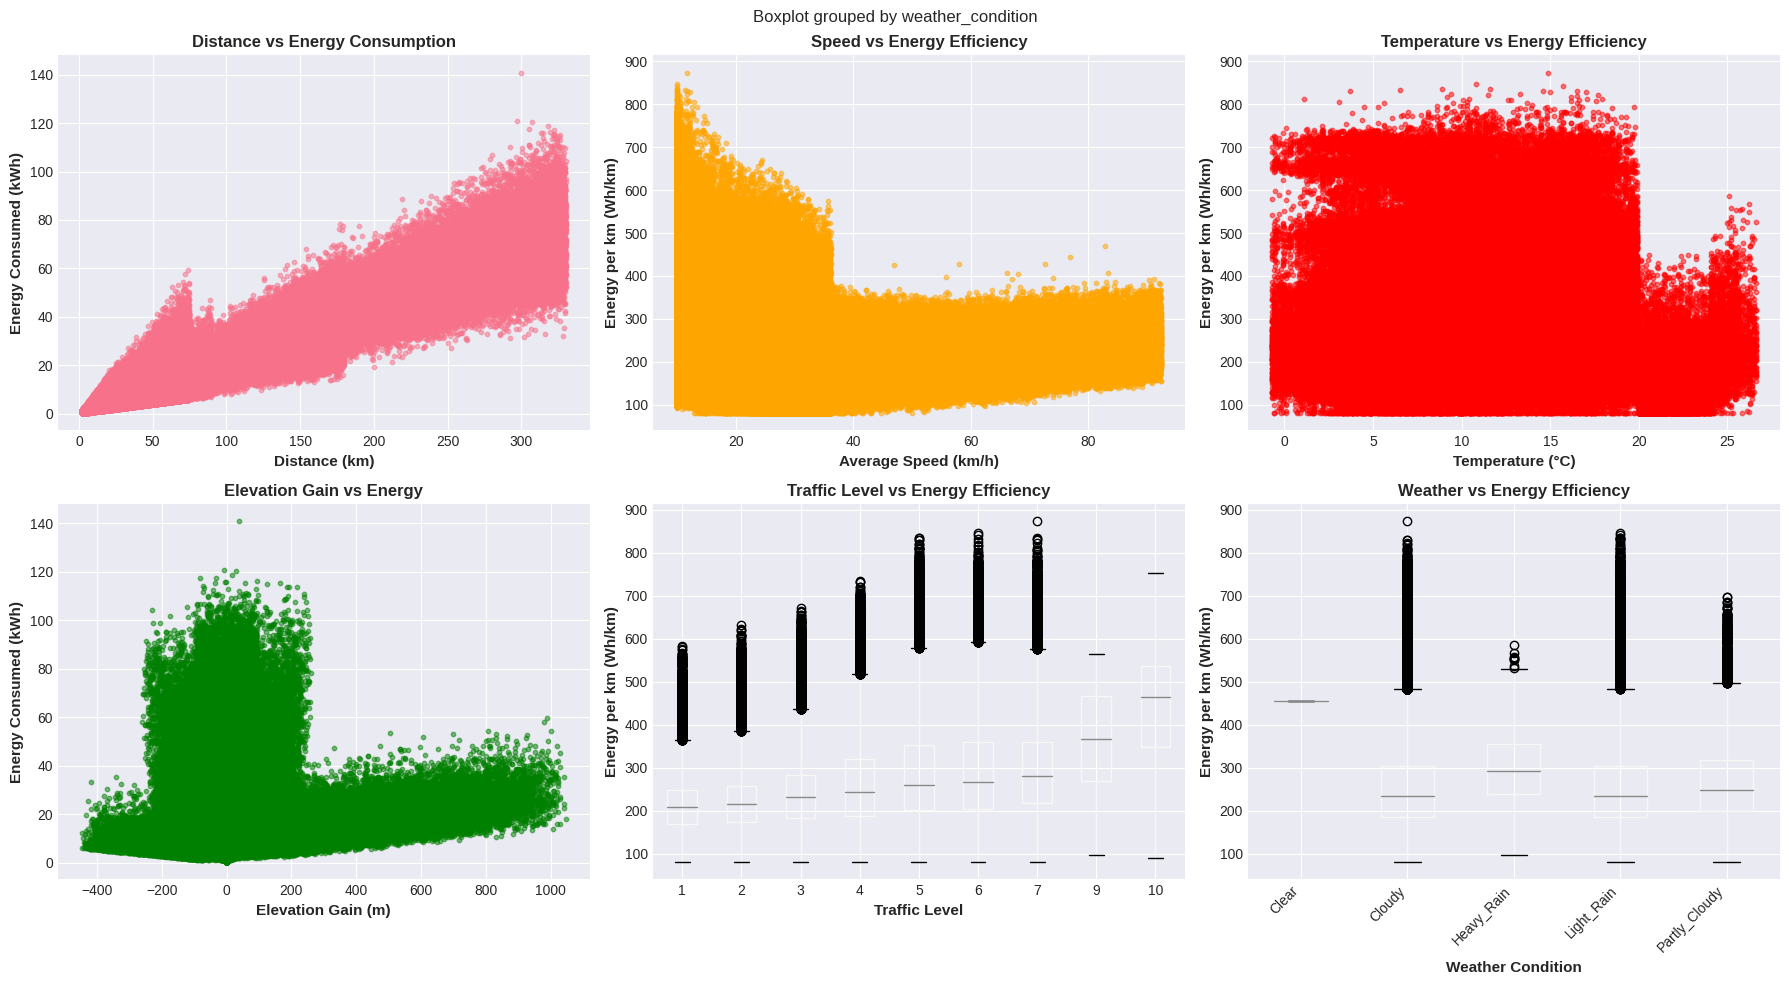

In [5]:
print("\n" + "="*80)
print("📊 KEY FEATURE RELATIONSHIPS")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Distance vs Energy
axes[0, 0].scatter(df['distance_km'], df['energy_consumed_kWh'], alpha=0.5, s=10)
axes[0, 0].set_xlabel('Distance (km)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Energy Consumed (kWh)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Distance vs Energy Consumption', fontsize=12, fontweight='bold')

# Speed vs Energy per km
axes[0, 1].scatter(df['avg_speed_kmh'], df['energy_per_km_Whkm'], alpha=0.5, s=10, color='orange')
axes[0, 1].set_xlabel('Average Speed (km/h)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Energy per km (Wh/km)', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Speed vs Energy Efficiency', fontsize=12, fontweight='bold')

# Temperature vs Energy per km
axes[0, 2].scatter(df['ambient_temp_celsius'], df['energy_per_km_Whkm'], alpha=0.5, s=10, color='red')
axes[0, 2].set_xlabel('Temperature (°C)', fontsize=11, fontweight='bold')
axes[0, 2].set_ylabel('Energy per km (Wh/km)', fontsize=11, fontweight='bold')
axes[0, 2].set_title('Temperature vs Energy Efficiency', fontsize=12, fontweight='bold')

# Elevation gain vs Energy
axes[1, 0].scatter(df['elevation_gain_m'], df['energy_consumed_kWh'], alpha=0.5, s=10, color='green')
axes[1, 0].set_xlabel('Elevation Gain (m)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Energy Consumed (kWh)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Elevation Gain vs Energy', fontsize=12, fontweight='bold')

# Traffic level vs Energy per km
df.boxplot(column='energy_per_km_Whkm', by='traffic_level', ax=axes[1, 1])
axes[1, 1].set_xlabel('Traffic Level', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Energy per km (Wh/km)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Traffic Level vs Energy Efficiency', fontsize=12, fontweight='bold')

# Weather condition vs Energy per km
df.boxplot(column='energy_per_km_Whkm', by='weather_condition', ax=axes[1, 2])
axes[1, 2].set_xlabel('Weather Condition', fontsize=11, fontweight='bold')
axes[1, 2].set_ylabel('Energy per km (Wh/km)', fontsize=11, fontweight='bold')
axes[1, 2].set_title('Weather vs Energy Efficiency', fontsize=12, fontweight='bold')
plt.setp(axes[1, 2].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('02_feature_relationships.png', dpi=300, bbox_inches='tight')
plt.show()



📊 CORRELATION ANALYSIS

🔗 Top 15 Features Correlated with Energy Consumption:
energy_consumed_kWh     1.000000
distance_km             0.942342
trip_duration_hours     0.777310
battery_used_percent    0.739274
road_surface_quality    0.726491
avg_speed_kmh           0.677676
payload_kg              0.415017
passenger_count         0.279572
total_mass_kg           0.222663
frontal_area_m2         0.176367
hvac_power_kW           0.169457
vehicle_weight_kg       0.159108
battery_capacity_kWh    0.149116
stop_count              0.127251
regen_efficiency        0.083697
Name: energy_consumed_kWh, dtype: float64


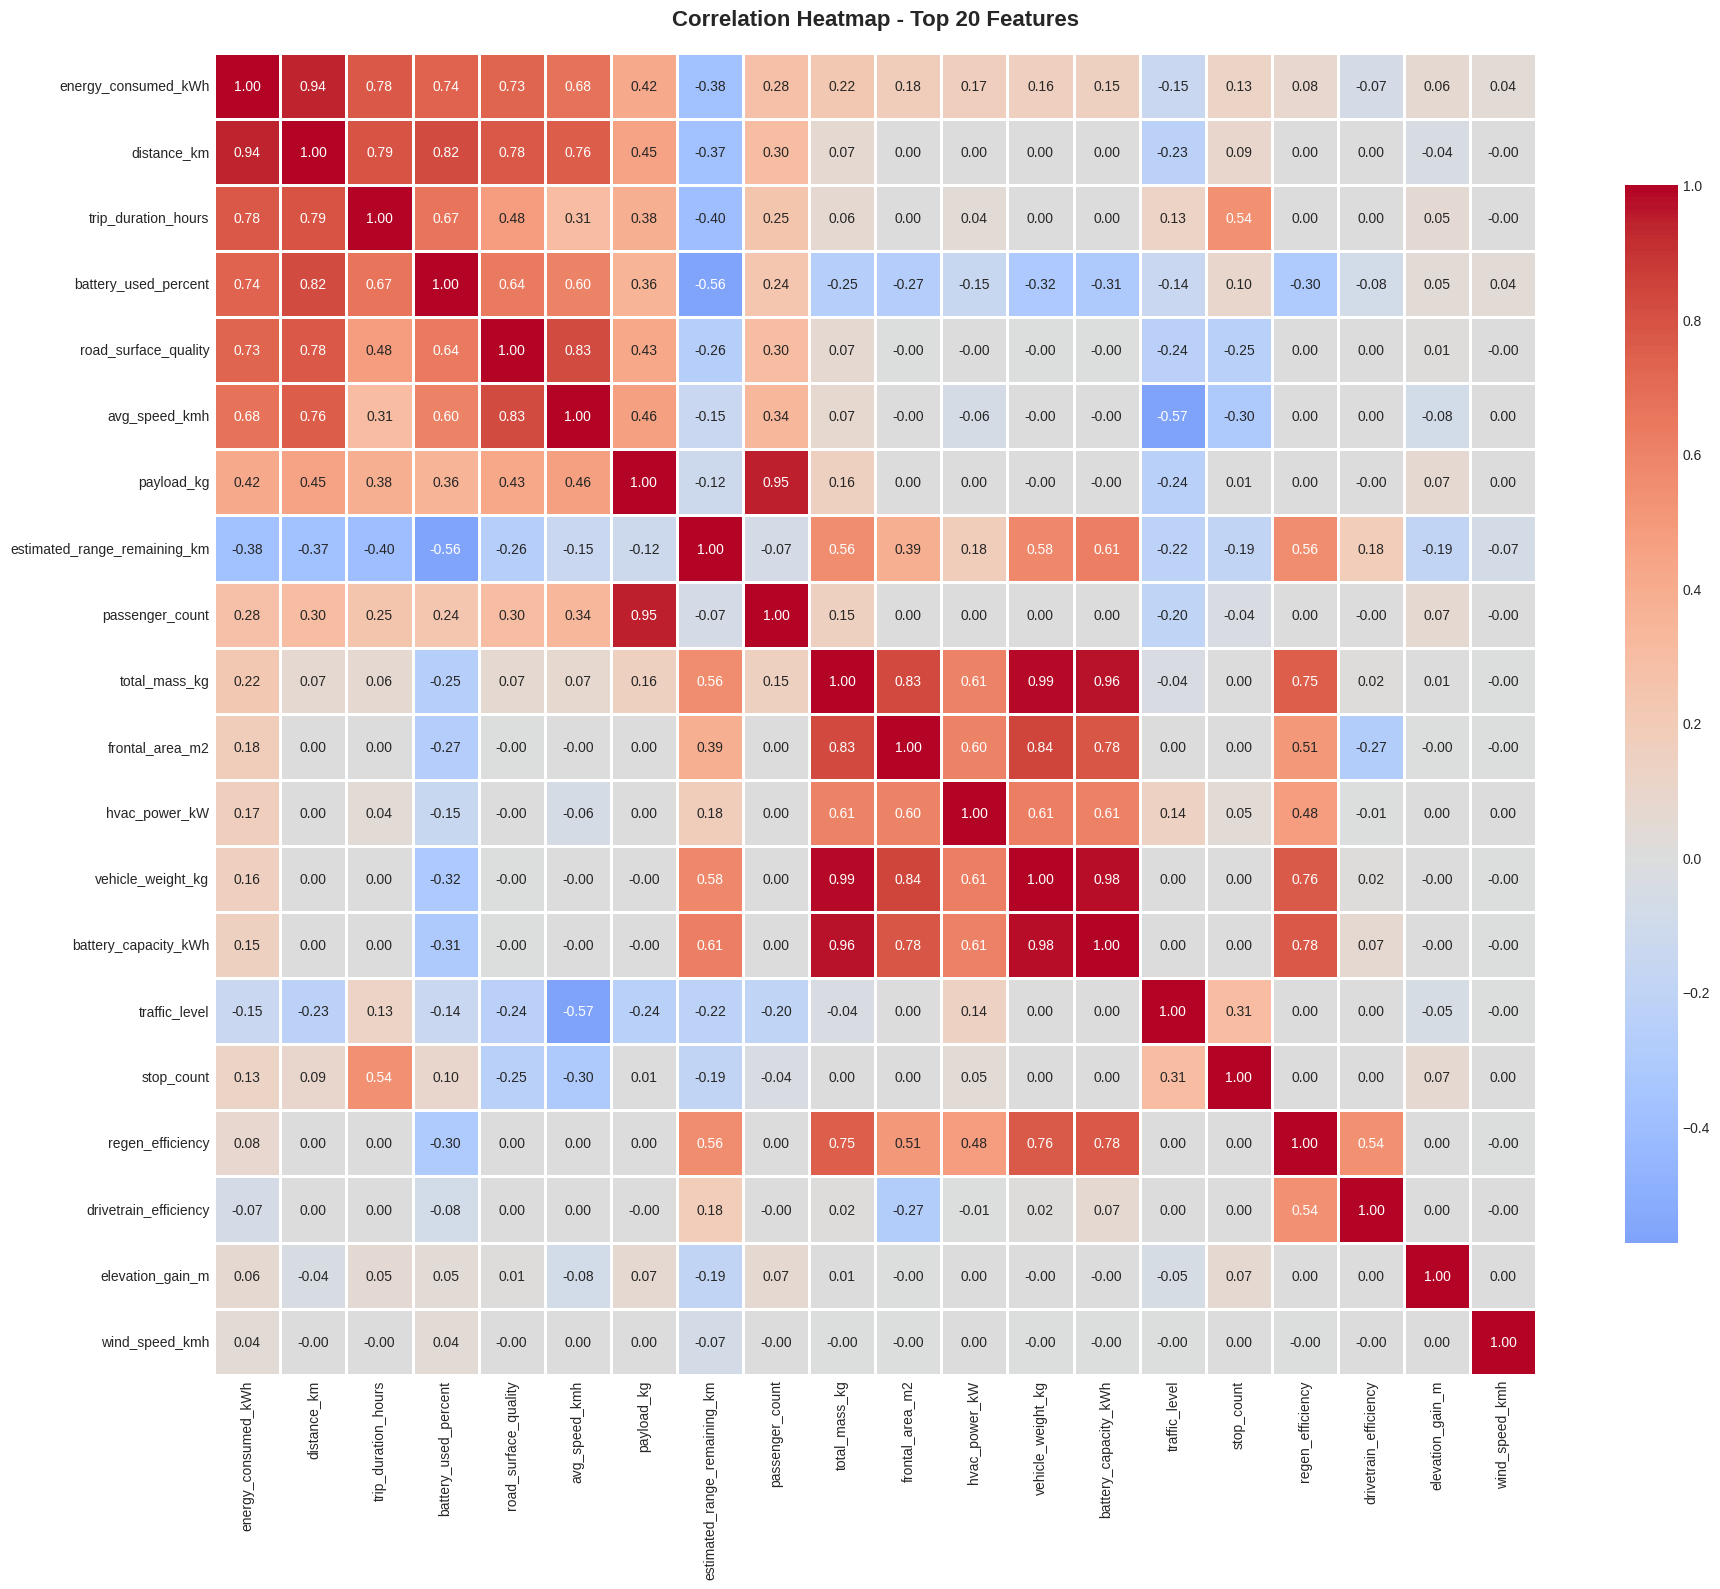

In [6]:
print("\n" + "="*80)
print("📊 CORRELATION ANALYSIS")
print("="*80)

# Select numerical features for correlation
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Compute correlation with target
correlations = df[numerical_cols].corr()['energy_consumed_kWh'].sort_values(ascending=False)
print("\n🔗 Top 15 Features Correlated with Energy Consumption:")
print(correlations.head(15))

# Correlation heatmap
fig, ax = plt.subplots(figsize=(20, 16))
important_features = correlations.abs().sort_values(ascending=False).head(20).index
correlation_matrix = df[important_features].corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title('Correlation Heatmap - Top 20 Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('03_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
print("\n" + "="*80)
print("🔬 STAGE 2: PHYSICS-INFORMED FEATURE ENGINEERING")
print("="*80)

df_engineered = df.copy()

# 1. PHYSICS-BASED THEORETICAL ENERGY (Baseline)
print("\n🔬 Computing Theoretical Energy Components...")

g = 9.81  # gravity (m/s²)

# Rolling resistance energy (kWh)
df_engineered['physics_rolling_energy'] = (
    df['rolling_resistance_coeff'] * df['total_mass_kg'] * g * 
    df['distance_km'] * 1000 / 3600 / 1000
)

# Aerodynamic drag energy (kWh) - simplified
df_engineered['physics_aero_energy'] = (
    0.5 * df['drag_coefficient'] * 1.225 * df['frontal_area_m2'] * 
    (df['avg_speed_kmh'] / 3.6) ** 3 * df['trip_duration_hours'] * 3600 / 3600 / 1000
)

# Potential energy (kWh)
df_engineered['physics_potential_energy'] = (
    df['total_mass_kg'] * g * df['elevation_gain_m'] / 3600 / 1000
)

# Total theoretical energy
df_engineered['physics_theoretical_energy'] = (
    df_engineered['physics_rolling_energy'] + 
    df_engineered['physics_aero_energy'] + 
    df_engineered['physics_potential_energy']
).apply(lambda x: max(x, 0.1))  # Minimum threshold

# Residual energy (what ML needs to learn)
df_engineered['physics_residual'] = (
    df['energy_consumed_kWh'] - df_engineered['physics_theoretical_energy']
)

print(f"✅ Theoretical Energy Mean: {df_engineered['physics_theoretical_energy'].mean():.2f} kWh")
print(f"✅ Actual Energy Mean: {df['energy_consumed_kWh'].mean():.2f} kWh")
print(f"✅ Residual Mean: {df_engineered['physics_residual'].mean():.2f} kWh")

# 2. DRIVER BEHAVIOR METRICS
print("\n👤 Computing Driver Behavior Indices...")

# Driver Aggressiveness Index (DAI)
df_engineered['driver_aggressiveness_index'] = (
    (df['stop_count'] / (df['distance_km'] + 0.1)) * df['traffic_level'] * 
    (df['avg_speed_kmh'] / 50)  # Normalized by typical speed
)

# Driver-Vehicle Interaction Index (DVII)
df_engineered['driver_vehicle_interaction'] = (
    df_engineered['driver_aggressiveness_index'] * df['regen_efficiency'] * 
    (df['battery_capacity_kWh'] / 50)  # Normalized battery size
)

# Stop intensity
df_engineered['stop_intensity'] = df['stop_count'] / (df['distance_km'] + 0.1)

print(f"✅ DAI Range: [{df_engineered['driver_aggressiveness_index'].min():.2f}, "
      f"{df_engineered['driver_aggressiveness_index'].max():.2f}]")

# 3. ROUTE COMPLEXITY METRICS
print("\n🛣️ Computing Route Complexity Features...")

# Gradient severity
df_engineered['gradient_severity'] = np.abs(df['road_gradient_percent'])

# Route energy complexity score
df_engineered['route_complexity_score'] = (
    df_engineered['gradient_severity'] * df['distance_km'] * 
    (1 - df['road_surface_quality']) * df['traffic_level'] / 10
)

# Elevation intensity
df_engineered['elevation_intensity'] = (
    np.abs(df['elevation_gain_m']) / (df['distance_km'] + 0.1)
)

# Speed variance proxy (from road type characteristics)
speed_variance_map = {
    'Expressway': 0.1, 'National_Highway': 0.15, 'State_Highway': 0.2,
    'Rural_Road': 0.25, 'Ghat_Section': 0.3, 'Urban_Arterial': 0.35,
    'Urban_Collector': 0.4, 'Urban_Local': 0.45
}
df_engineered['speed_variance_proxy'] = df['road_type'].map(speed_variance_map)

print(f"✅ Route Complexity Score Range: [{df_engineered['route_complexity_score'].min():.2f}, "
      f"{df_engineered['route_complexity_score'].max():.2f}]")

# 4. ENVIRONMENTAL STRESS FACTORS
print("\n🌡️ Computing Environmental Stress Features...")

# Thermal stress (deviation from optimal 20-24°C)
df_engineered['thermal_stress'] = np.abs(df['ambient_temp_celsius'] - 22)

# HVAC load intensity
df_engineered['hvac_load_intensity'] = (
    df['hvac_power_kW'] * df['trip_duration_hours'] / 
    (df['distance_km'] + 0.1)
)

# Weather severity index
weather_severity = {
    'Clear': 0, 'Partly_Cloudy': 0.2, 'Cloudy': 0.3,
    'Light_Rain': 0.5, 'Heavy_Rain': 0.8, 'Hot_Humid': 0.6
}
df_engineered['weather_severity'] = df['weather_condition'].map(weather_severity)

# Combined environmental stress
df_engineered['environmental_stress'] = (
    df_engineered['thermal_stress'] * df['humidity_percent'] / 100 * 
    df_engineered['weather_severity'] * (1 + df['wind_speed_kmh'] / 20)
)

print(f"✅ Environmental Stress Range: [{df_engineered['environmental_stress'].min():.2f}, "
      f"{df_engineered['environmental_stress'].max():.2f}]")

# 5. VEHICLE EFFICIENCY METRICS
print("\n🚗 Computing Vehicle Efficiency Metrics...")

# Power-to-weight ratio
df_engineered['power_to_weight_ratio'] = (
    df['battery_capacity_kWh'] / (df['total_mass_kg'] / 1000)
)

# Aerodynamic efficiency (FIXED: frontalArea_m2 -> frontal_area_m2)
df_engineered['aero_efficiency'] = (
    1 / (df['drag_coefficient'] * df['frontal_area_m2'] + 0.0001)  # Added small constant to avoid division by zero
)

# Combined drivetrain score
df_engineered['drivetrain_quality_score'] = (
    df['drivetrain_efficiency'] * df['regen_efficiency'] * 
    (1 - df['rolling_resistance_coeff'] * 100)
)

print(f"✅ Power-to-Weight Ratio Mean: {df_engineered['power_to_weight_ratio'].mean():.2f}")

# 6. INTERACTION FEATURES
print("\n🔗 Computing Interaction Features...")

# Speed-temperature interaction
df_engineered['speed_temp_interaction'] = (
    df['avg_speed_kmh'] * df['ambient_temp_celsius'] / 1000
)

# Traffic-gradient interaction
df_engineered['traffic_gradient_interaction'] = (
    df['traffic_level'] * np.abs(df['road_gradient_percent'])
)

# Distance-efficiency interaction
df_engineered['distance_efficiency_interaction'] = (
    df['distance_km'] * df['drivetrain_efficiency']
)

# Payload-gradient interaction
df_engineered['payload_gradient_interaction'] = (
    df['payload_kg'] * np.abs(df['road_gradient_percent']) / 100
)

print(f"\n✅ Total Engineered Features: {len(df_engineered.columns) - len(df.columns)}")
print(f"✅ Total Features: {len(df_engineered.columns)}")

# Display summary statistics of key engineered features
print("\n" + "="*80)
print("📊 KEY ENGINEERED FEATURES SUMMARY")
print("="*80)
key_features = [
    'physics_theoretical_energy', 'physics_residual', 
    'driver_aggressiveness_index', 'route_complexity_score',
    'environmental_stress', 'aero_efficiency'
]
print(df_engineered[key_features].describe().round(3))


🔬 STAGE 2: PHYSICS-INFORMED FEATURE ENGINEERING

🔬 Computing Theoretical Energy Components...
✅ Theoretical Energy Mean: 5.99 kWh
✅ Actual Energy Mean: 16.15 kWh
✅ Residual Mean: 10.17 kWh

👤 Computing Driver Behavior Indices...
✅ DAI Range: [0.05, 3.70]

🛣️ Computing Route Complexity Features...
✅ Route Complexity Score Range: [0.00, 15.84]

🌡️ Computing Environmental Stress Features...
✅ Environmental Stress Range: [0.00, 18.70]

🚗 Computing Vehicle Efficiency Metrics...
✅ Power-to-Weight Ratio Mean: 26.71

🔗 Computing Interaction Features...

✅ Total Engineered Features: 23
✅ Total Features: 59

📊 KEY ENGINEERED FEATURES SUMMARY
       physics_theoretical_energy  physics_residual  \
count                  400000.000        400000.000   
mean                        5.986            10.166   
std                         7.921             9.485   
min                         0.100             0.075   
25%                         0.874             3.334   
50%                         2


🗺️ STAGE 3: ROUTE SIGNATURE EMBEDDINGS (NOVEL)

🔧 Creating Route Signature Vectors...
✅ Route embeddings created: 3D representation
✅ Explained variance: 93.29%


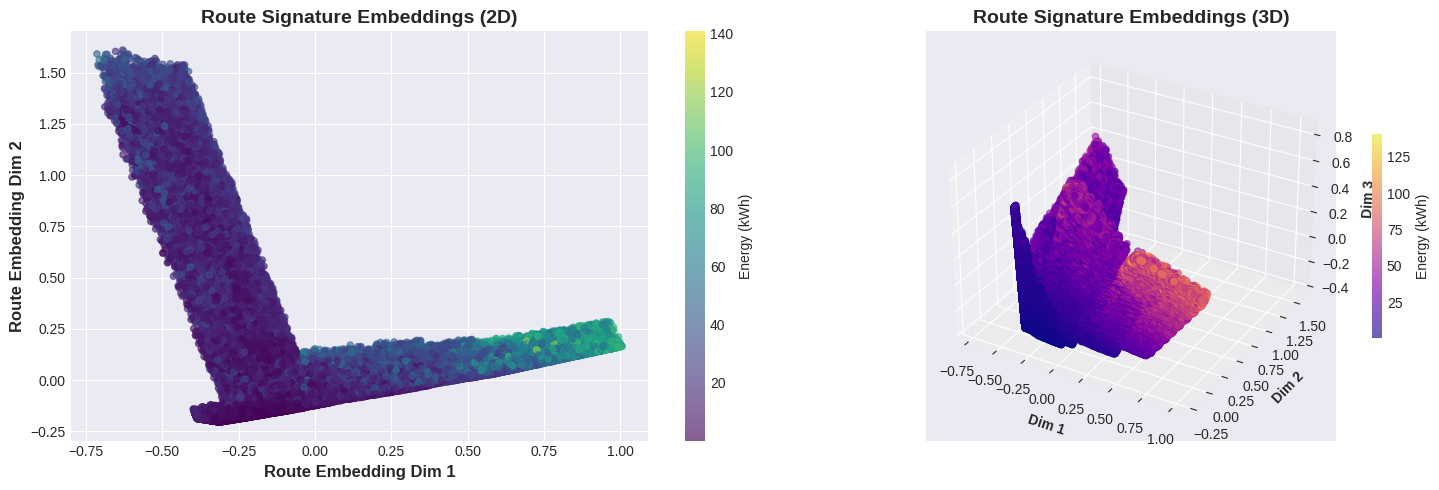

In [8]:
print("\n" + "="*80)
print("🗺️ STAGE 3: ROUTE SIGNATURE EMBEDDINGS (NOVEL)")
print("="*80)

print("\n🔧 Creating Route Signature Vectors...")

# Create a route signature based on key spatial characteristics
route_signature_features = [
    'distance_km', 'elevation_gain_m', 'road_gradient_percent',
    'avg_speed_kmh', 'stop_count', 'route_complexity_score',
    'gradient_severity', 'elevation_intensity'
]

# Normalize route features for embedding
from sklearn.preprocessing import MinMaxScaler
route_scaler = MinMaxScaler()
route_signatures = route_scaler.fit_transform(df_engineered[route_signature_features])

# Simple dimensionality reduction for visualization (PCA)
from sklearn.decomposition import PCA

pca_route = PCA(n_components=3)
route_embeddings_3d = pca_route.fit_transform(route_signatures)

df_engineered['route_embed_1'] = route_embeddings_3d[:, 0]
df_engineered['route_embed_2'] = route_embeddings_3d[:, 1]
df_engineered['route_embed_3'] = route_embeddings_3d[:, 2]

print(f"✅ Route embeddings created: 3D representation")
print(f"✅ Explained variance: {pca_route.explained_variance_ratio_.sum():.2%}")

# Visualize route embeddings colored by energy consumption
fig = plt.figure(figsize=(15, 5))

# 2D projection
ax1 = fig.add_subplot(121)
scatter = ax1.scatter(route_embeddings_3d[:, 0], route_embeddings_3d[:, 1],
                     c=df_engineered['energy_consumed_kWh'], cmap='viridis', 
                     alpha=0.6, s=20)
ax1.set_xlabel('Route Embedding Dim 1', fontsize=12, fontweight='bold')
ax1.set_ylabel('Route Embedding Dim 2', fontsize=12, fontweight='bold')
ax1.set_title('Route Signature Embeddings (2D)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=ax1, label='Energy (kWh)')

# 3D projection
ax2 = fig.add_subplot(122, projection='3d')
scatter3d = ax2.scatter(route_embeddings_3d[:, 0], route_embeddings_3d[:, 1], 
                        route_embeddings_3d[:, 2],
                        c=df_engineered['energy_consumed_kWh'], cmap='plasma', 
                        alpha=0.6, s=20)
ax2.set_xlabel('Dim 1', fontsize=10, fontweight='bold')
ax2.set_ylabel('Dim 2', fontsize=10, fontweight='bold')
ax2.set_zlabel('Dim 3', fontsize=10, fontweight='bold')
ax2.set_title('Route Signature Embeddings (3D)', fontsize=14, fontweight='bold')
plt.colorbar(scatter3d, ax=ax2, label='Energy (kWh)', shrink=0.5)

plt.tight_layout()
plt.savefig('04_route_embeddings.png', dpi=300, bbox_inches='tight')
plt.show()


In [9]:
print("\n" + "="*80)
print("📋 FEATURE ENGINEERING SUMMARY")
print("="*80)

print(f"\n📊 Total Features: {len(df_engineered.columns)}")
print(f"📊 Original Features: {len(df.columns)}")
print(f"📊 Engineered Features: {len(df_engineered.columns) - len(df.columns)}")

print("\n🆕 Novel Engineered Features:")
new_features = [col for col in df_engineered.columns if col not in df.columns]
for i, feat in enumerate(new_features, 1):
    print(f"  {i:2d}. {feat}")

# Save engineered dataset
df_engineered.to_csv('ev_dataset_engineered.csv', index=False)
print(f"\n💾 Engineered dataset saved: ev_dataset_engineered.csv")

print("\n" + "="*80)


📋 FEATURE ENGINEERING SUMMARY

📊 Total Features: 62
📊 Original Features: 36
📊 Engineered Features: 26

🆕 Novel Engineered Features:
   1. physics_rolling_energy
   2. physics_aero_energy
   3. physics_potential_energy
   4. physics_theoretical_energy
   5. physics_residual
   6. driver_aggressiveness_index
   7. driver_vehicle_interaction
   8. stop_intensity
   9. gradient_severity
  10. route_complexity_score
  11. elevation_intensity
  12. speed_variance_proxy
  13. thermal_stress
  14. hvac_load_intensity
  15. weather_severity
  16. environmental_stress
  17. power_to_weight_ratio
  18. aero_efficiency
  19. drivetrain_quality_score
  20. speed_temp_interaction
  21. traffic_gradient_interaction
  22. distance_efficiency_interaction
  23. payload_gradient_interaction
  24. route_embed_1
  25. route_embed_2
  26. route_embed_3

💾 Engineered dataset saved: ev_dataset_engineered.csv



In [10]:
print("\n" + "="*80)
print("🔧 STAGE 4: DATA PREPARATION FOR MODELING")
print("="*80)

# Define feature groups for multi-head architecture
print("\n📦 Defining Feature Groups for Multi-Head Architecture...")

# Physics features (Head A)
physics_features = [
    'physics_rolling_energy', 'physics_aero_energy', 'physics_potential_energy',
    'physics_theoretical_energy', 'rolling_resistance_coeff', 'drag_coefficient',
    'frontalArea_m2', 'drivetrain_efficiency', 'regen_efficiency'
]

# Route features (Head C)
route_features = [
    'distance_km', 'elevation_gain_m', 'road_gradient_percent', 'gradient_severity',
    'route_complexity_score', 'elevation_intensity', 'stop_count', 'stop_intensity',
    'route_embed_1', 'route_embed_2', 'route_embed_3'
]

# Environmental features (Head B - part 1)
environmental_features = [
    'ambient_temp_celsius', 'humidity_percent', 'wind_speed_kmh',
    'thermal_stress', 'hvac_load_intensity', 'weather_severity',
    'environmental_stress', 'hvac_power_kW'
]

# Traffic & behavior features (Head B - part 2)
traffic_behavior_features = [
    'avg_speed_kmh', 'traffic_level', 'driver_aggressiveness_index',
    'driver_vehicle_interaction', 'speed_variance_proxy',
    'road_surface_quality'
]

# Vehicle features
vehicle_features = [
    'battery_capacity_kWh', 'vehicle_weight_kg', 'total_mass_kg', 'payload_kg',
    'power_to_weight_ratio', 'aero_efficiency', 'drivetrain_quality_score'
]

# Interaction features
interaction_features = [
    'speed_temp_interaction', 'traffic_gradient_interaction',
    'distance_efficiency_interaction', 'payload_gradient_interaction'
]

# Time features
time_features = ['hour_of_day', 'trip_duration_hours']

# Categorical features (to be encoded)
categorical_features = [
    'city', 'road_type', 'weather_condition', 'time_of_day', 'vehicle_model'
]

print(f"✅ Physics Features: {len(physics_features)}")
print(f"✅ Route Features: {len(route_features)}")
print(f"✅ Environmental Features: {len(environmental_features)}")
print(f"✅ Traffic/Behavior Features: {len(traffic_behavior_features)}")
print(f"✅ Vehicle Features: {len(vehicle_features)}")
print(f"✅ Interaction Features: {len(interaction_features)}")
print(f"✅ Time Features: {len(time_features)}")
print(f"✅ Categorical Features: {len(categorical_features)}")



🔧 STAGE 4: DATA PREPARATION FOR MODELING

📦 Defining Feature Groups for Multi-Head Architecture...
✅ Physics Features: 9
✅ Route Features: 11
✅ Environmental Features: 8
✅ Traffic/Behavior Features: 6
✅ Vehicle Features: 7
✅ Interaction Features: 4
✅ Time Features: 2
✅ Categorical Features: 5


In [11]:
print("\n" + "="*80)
print("🔤 ENCODING CATEGORICAL FEATURES")
print("="*80)

df_model = df_engineered.copy()

# Label encoding for categorical features
label_encoders = {}
for cat_feat in categorical_features:
    le = LabelEncoder()
    df_model[f'{cat_feat}_encoded'] = le.fit_transform(df_model[cat_feat])
    label_encoders[cat_feat] = le
    print(f"✅ Encoded {cat_feat}: {len(le.classes_)} unique values")

# Update categorical features list
categorical_features_encoded = [f'{cat}_encoded' for cat in categorical_features]



🔤 ENCODING CATEGORICAL FEATURES
✅ Encoded city: 35 unique values
✅ Encoded road_type: 8 unique values
✅ Encoded weather_condition: 5 unique values
✅ Encoded time_of_day: 8 unique values
✅ Encoded vehicle_model: 20 unique values


In [12]:
print("\n" + "="*80)
print("📊 TRAIN-TEST SPLIT")
print("="*80)

# Combine all numerical features
all_numerical_features = (physics_features + route_features + environmental_features +
                         traffic_behavior_features + vehicle_features + 
                         interaction_features + time_features + categorical_features_encoded)

# Remove target and ID columns
features_to_use = [f for f in all_numerical_features if f in df_model.columns]

# Add residual to features (for physics-informed learning)
features_to_use.append('physics_residual')

X = df_model[features_to_use].values
y = df_model['energy_consumed_kWh'].values

print(f"\n✅ Feature Matrix Shape: {X.shape}")
print(f"✅ Target Shape: {y.shape}")
print(f"✅ Total Features Used: {len(features_to_use)}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"\n📊 Training Set: {X_train.shape[0]} samples")
print(f"📊 Test Set: {X_test.shape[0]} samples")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ Features standardized (mean=0, std=1)")

# Create feature dictionaries for multi-head model
def create_feature_dict(X_scaled, features_list):
    """Create dictionary mapping feature groups to their data"""
    feature_dict = {}
    
    # Get indices for each feature group
    physics_idx = [features_list.index(f) for f in physics_features if f in features_list]
    route_idx = [features_list.index(f) for f in route_features if f in features_list]
    env_idx = [features_list.index(f) for f in environmental_features if f in features_list]
    traffic_idx = [features_list.index(f) for f in traffic_behavior_features if f in features_list]
    vehicle_idx = [features_list.index(f) for f in vehicle_features if f in features_list]
    interaction_idx = [features_list.index(f) for f in interaction_features if f in features_list]
    time_idx = [features_list.index(f) for f in time_features if f in features_list]
    cat_idx = [features_list.index(f) for f in categorical_features_encoded if f in features_list]
    
    # Extract data for each group
    feature_dict['physics'] = X_scaled[:, physics_idx] if physics_idx else X_scaled[:, :len(physics_features)]
    feature_dict['route'] = X_scaled[:, route_idx] if route_idx else X_scaled[:, :len(route_features)]
    feature_dict['environmental'] = X_scaled[:, env_idx] if env_idx else X_scaled[:, :len(environmental_features)]
    feature_dict['traffic'] = X_scaled[:, traffic_idx] if traffic_idx else X_scaled[:, :len(traffic_behavior_features)]
    feature_dict['vehicle'] = X_scaled[:, vehicle_idx] if vehicle_idx else X_scaled[:, :len(vehicle_features)]
    feature_dict['interaction'] = X_scaled[:, interaction_idx] if interaction_idx else X_scaled[:, :len(interaction_features)]
    
    return feature_dict

# For now, we'll use combined features for simplicity
# Multi-head architecture will be implemented in the next cell

print("\n✅ Data preparation complete!")


📊 TRAIN-TEST SPLIT

✅ Feature Matrix Shape: (400000, 52)
✅ Target Shape: (400000,)
✅ Total Features Used: 52

📊 Training Set: 320000 samples
📊 Test Set: 80000 samples

✅ Features standardized (mean=0, std=1)

✅ Data preparation complete!


In [13]:
print("\n" + "="*80)
print("🧠 STAGE 5: MULTI-HEAD NEURAL NETWORK ARCHITECTURE")
print("="*80)

def build_multihead_model(input_dim):
    """
    Novel Multi-Head Architecture:
    - Head A: Physics Pathway (deterministic baseline)
    - Head B: Data-Driven Pathway (environmental + traffic + behavior)
    - Head C: Route Embedding Pathway (spatial intelligence)
    """
    
    # Input layer
    input_layer = layers.Input(shape=(input_dim,), name='input')
    
    # ========== HEAD A: PHYSICS PATHWAY ==========
    # Processes physics-based features
    physics_head = layers.Dense(64, activation='relu', name='physics_dense1')(input_layer)
    physics_head = layers.BatchNormalization(name='physics_bn1')(physics_head)
    physics_head = layers.Dropout(0.2, name='physics_dropout1')(physics_head)
    physics_head = layers.Dense(32, activation='relu', name='physics_dense2')(physics_head)
    physics_head = layers.BatchNormalization(name='physics_bn2')(physics_head)
    physics_output = layers.Dense(16, activation='relu', name='physics_output')(physics_head)
    
    # ========== HEAD B: DATA-DRIVEN PATHWAY ==========
    # Learns complex non-linear patterns from environment, traffic, behavior
    data_head = layers.Dense(128, activation='relu', name='data_dense1')(input_layer)
    data_head = layers.BatchNormalization(name='data_bn1')(data_head)
    data_head = layers.Dropout(0.3, name='data_dropout1')(data_head)
    data_head = layers.Dense(64, activation='relu', name='data_dense2')(data_head)
    data_head = layers.BatchNormalization(name='data_bn2')(data_head)
    data_head = layers.Dropout(0.2, name='data_dropout2')(data_head)
    data_head = layers.Dense(32, activation='relu', name='data_dense3')(data_head)
    data_output = layers.Dense(16, activation='relu', name='data_output')(data_head)
    
    # ========== HEAD C: ROUTE EMBEDDING PATHWAY ==========
    # Captures spatial/topological patterns
    route_head = layers.Dense(64, activation='relu', name='route_dense1')(input_layer)
    route_head = layers.BatchNormalization(name='route_bn1')(route_head)
    route_head = layers.Dropout(0.2, name='route_dropout1')(route_head)
    route_head = layers.Dense(32, activation='relu', name='route_dense2')(route_head)
    route_output = layers.Dense(16, activation='relu', name='route_output')(route_head)
    
    # ========== FUSION LAYER ==========
    # Concatenate all heads
    fusion = layers.Concatenate(name='fusion')([physics_output, data_output, route_output])
    
    # Final dense layers
    fusion = layers.Dense(64, activation='relu', name='fusion_dense1')(fusion)
    fusion = layers.BatchNormalization(name='fusion_bn')(fusion)
    fusion = layers.Dropout(0.2, name='fusion_dropout')(fusion)
    fusion = layers.Dense(32, activation='relu', name='fusion_dense2')(fusion)
    fusion = layers.Dense(16, activation='relu', name='fusion_dense3')(fusion)
    
    # Output layer (energy prediction)
    output = layers.Dense(1, activation='linear', name='energy_output')(fusion)
    
    # Build model
    model = Model(inputs=input_layer, outputs=output, name='MultiHead_EV_Energy_Predictor')
    
    return model

# Build the model
print("\n🏗️ Building Multi-Head Model...")
model = build_multihead_model(X_train_scaled.shape[1])

# Compile with custom loss and metrics
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='huber',  # Robust to outliers
    metrics=['mae', 'mse', tf.keras.metrics.RootMeanSquaredError(name='rmse')]
)

print("\n✅ Model Architecture:")
model.summary()

# Visualize model architecture
tf.keras.utils.plot_model(
    model, 
    to_file='05_model_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB',
    dpi=150
)
print("\n✅ Model architecture diagram saved: 05_model_architecture.png")


🧠 STAGE 5: MULTI-HEAD NEURAL NETWORK ARCHITECTURE

🏗️ Building Multi-Head Model...


I0000 00:00:1760523570.282380      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



✅ Model Architecture:


Model: "MultiHead_EV_Energy_Predictor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 52)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_dense1 (Dense) │ (None, 128)       │      6,784 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_bn1            │ (None, 128)       │        512 │ data_dense1[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ physics_dense1      │ (None, 64)        │      3,392 │ input[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_dropout1       │ (None, 128)       │          0 │ data_bn1[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ physics_bn1         │ (None, 64)        │        256 │ physics_dense1[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_dense2 (Dense) │ (None, 64)        │      8,256 │ data_dropout1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ route_dense1        │ (None, 64)        │      3,392 │ input[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ physics_dropout1    │ (None, 64)        │          0 │ physics_bn1[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_bn2            │ (None, 64)        │        256 │ data_dense2[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ route_bn1           │ (None, 64)        │        256 │ route_dense1[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ physics_dense2      │ (None, 32)        │      2,080 │ physics_dropout1… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_dropout2       │ (None, 64)        │          0 │ data_bn2[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ route_dropout1      │ (None, 64)        │          0 │ route_bn1[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ physics_bn2         │ (None, 32)        │        128 │ physics_dense2[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_dense3 (Dense) │ (None, 32)        │      2,080 │ data_dropout2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ route_dense2        │ (None, 32)        │      2,080 │ route_dropout1[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ physics_output      │ (None, 16)        │        528 │ physics_bn2[0][0] │
│ (Dense)             │                   │            │                 

 Total params: 37,073 (144.82 KB)

 Trainable params: 36,241 (141.57 KB)

 Non-trainable params: 832 (3.25 KB)


✅ Model architecture diagram saved: 05_model_architecture.png


In [14]:
print("\n" + "="*80)
print("🚀 STAGE 6: MODEL TRAINING")
print("="*80)

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

# Train the model
print("\n🎯 Training Multi-Head Model...")
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\n✅ Training Complete!")
print(f"✅ Best Epoch: {early_stopping.best_epoch + 1}")
print(f"✅ Best Val Loss: {min(history.history['val_loss']):.4f}")


🚀 STAGE 6: MODEL TRAINING

🎯 Training Multi-Head Model...
Epoch 1/200


I0000 00:00:1760523580.319647     102 service.cc:148] XLA service 0x79dce80038e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760523580.320176     102 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1760523581.153738     102 cuda_dnn.cc:529] Loaded cuDNN version 90300


  47/8000 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - loss: 15.0522 - mae: 15.5441 - mse: 516.4000 - rmse: 22.7178 

I0000 00:00:1760523585.062725     102 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8000/8000 ━━━━━━━━━━━━━━━━━━━━ 45s 4ms/step - loss: 2.4839 - mae: 2.9133 - mse: 35.8595 - rmse: 5.4004 - val_loss: 0.2529 - val_mae: 0.5987 - val_mse: 0.5635 - val_rmse: 0.7507 - learning_rate: 0.0010
Epoch 2/200
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - loss: 0.9584 - mae: 1.3499 - mse: 5.0880 - rmse: 2.2541 - val_loss: 0.4715 - val_mae: 0.8320 - val_mse: 1.5027 - val_rmse: 1.2258 - learning_rate: 0.0010
Epoch 3/200
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - loss: 0.7177 - mae: 1.0894 - mse: 3.3722 - rmse: 1.8355 - val_loss: 0.7178 - val_mae: 1.0838 - val_mse: 2.5755 - val_rmse: 1.6048 - learning_rate: 0.0010
Epoch 4/200
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - loss: 0.5696 - mae: 0.9254 - mse: 2.3703 - rmse: 1.5392 - val_loss: 0.8759 - val_mae: 1.1553 - val_mse: 5.3218 - val_rmse: 2.3069 - learning_rate: 0.0010
Epoch 5/200
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - loss: 0.4921 - mae: 0.8356 - mse: 1.9502 - rmse: 1.3961 - val_loss: 1.1336 - val_mae: 1.4019 - val_mse: 9


📈 TRAINING HISTORY VISUALIZATION


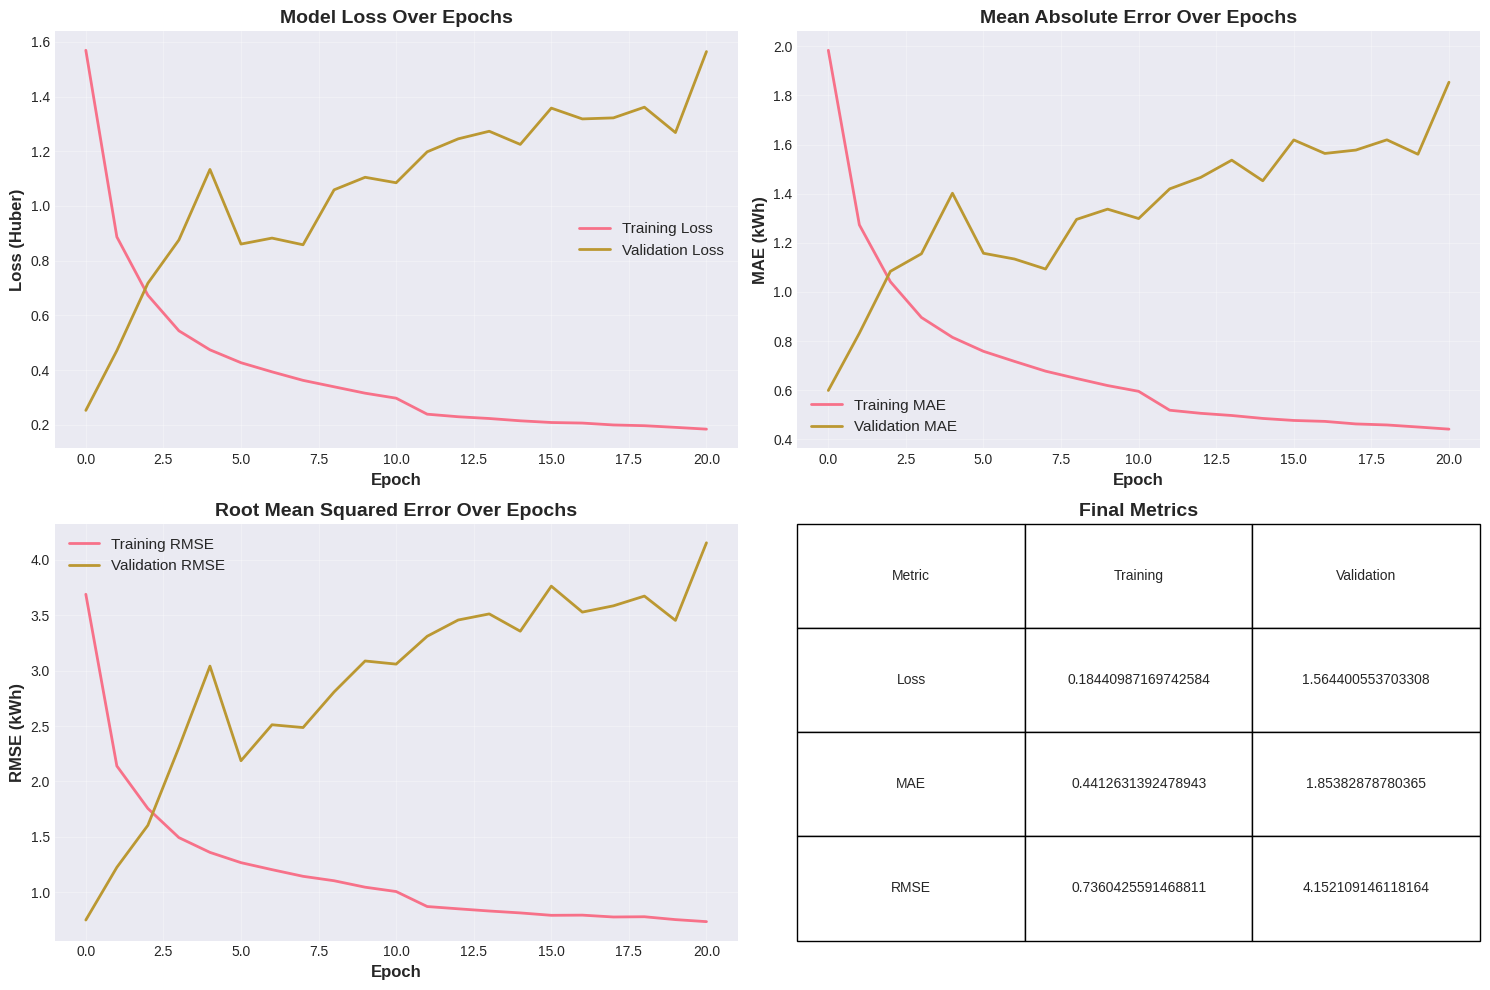

In [15]:
print("\n" + "="*80)
print("📈 TRAINING HISTORY VISUALIZATION")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss curves
axes[0, 0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Loss (Huber)', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# MAE curves
axes[0, 1].plot(history.history['mae'], label='Training MAE', linewidth=2)
axes[0, 1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[0, 1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('MAE (kWh)', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Mean Absolute Error Over Epochs', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# RMSE curves
axes[1, 0].plot(history.history['rmse'], label='Training RMSE', linewidth=2)
axes[1, 0].plot(history.history['val_rmse'], label='Validation RMSE', linewidth=2)
axes[1, 0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('RMSE (kWh)', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Root Mean Squared Error Over Epochs', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# Learning rate (if reduced)
if 'lr' in history.history:
    axes[1, 1].plot(history.history['lr'], linewidth=2, color='green')
    axes[1, 1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('Learning Rate', fontsize=12, fontweight='bold')
    axes[1, 1].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
    axes[1, 1].set_yscale('log')
    axes[1, 1].grid(True, alpha=0.3)
else:
    # Show validation metrics comparison
    final_metrics = pd.DataFrame({
        'Metric': ['Loss', 'MAE', 'RMSE'],
        'Training': [history.history['loss'][-1], 
                    history.history['mae'][-1],
                    history.history['rmse'][-1]],
        'Validation': [history.history['val_loss'][-1],
                      history.history['val_mae'][-1],
                      history.history['val_rmse'][-1]]
    })
    axes[1, 1].axis('off')
    table = axes[1, 1].table(cellText=final_metrics.values,
                            colLabels=final_metrics.columns,
                            cellLoc='center',
                            loc='center',
                            bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    axes[1, 1].set_title('Final Metrics', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('06_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
print("\n" + "="*80)
print("🎯 STAGE 7: MODEL EVALUATION")
print("="*80)

# Predictions
y_pred_train = model.predict(X_train_scaled, verbose=0).flatten()
y_pred_test = model.predict(X_test_scaled, verbose=0).flatten()

# Calculate metrics
def calculate_metrics(y_true, y_pred, dataset_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    
    print(f"\n{'='*60}")
    print(f"📊 {dataset_name} SET METRICS")
    print(f"{'='*60}")
    print(f"MAE (Mean Absolute Error):        {mae:.4f} kWh")
    print(f"MSE (Mean Squared Error):         {mse:.4f} kWh²")
    print(f"RMSE (Root Mean Squared Error):  {rmse:.4f} kWh")
    print(f"R² Score:                         {r2:.4f}")
    print(f"MAPE (Mean Absolute % Error):     {mape:.2f}%")
    print(f"{'='*60}")
    
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

train_metrics = calculate_metrics(y_train, y_pred_train, "TRAINING")
test_metrics = calculate_metrics(y_test, y_pred_test, "TEST")

# Check if target metrics are achieved
print("\n🎯 TARGET METRICS EVALUATION:")
print(f"{'='*60}")
print(f"Target MAE: ≤ 3.0 kWh  →  Achieved: {test_metrics['MAE']:.4f} kWh  {'✅' if test_metrics['MAE'] <= 3.0 else '❌'}")
print(f"Target R²:  ≥ 0.90     →  Achieved: {test_metrics['R2']:.4f}      {'✅' if test_metrics['R2'] >= 0.90 else '❌'}")
print(f"{'='*60}")


🎯 STAGE 7: MODEL EVALUATION

📊 TRAINING SET METRICS
MAE (Mean Absolute Error):        0.5990 kWh
MSE (Mean Squared Error):         0.5621 kWh²
RMSE (Root Mean Squared Error):  0.7497 kWh
R² Score:                         0.9980
MAPE (Mean Absolute % Error):     8.62%

📊 TEST SET METRICS
MAE (Mean Absolute Error):        0.5954 kWh
MSE (Mean Squared Error):         0.5578 kWh²
RMSE (Root Mean Squared Error):  0.7469 kWh
R² Score:                         0.9980
MAPE (Mean Absolute % Error):     8.56%

🎯 TARGET METRICS EVALUATION:
Target MAE: ≤ 3.0 kWh  →  Achieved: 0.5954 kWh  ✅
Target R²:  ≥ 0.90     →  Achieved: 0.9980      ✅



📊 PREDICTION VISUALIZATION


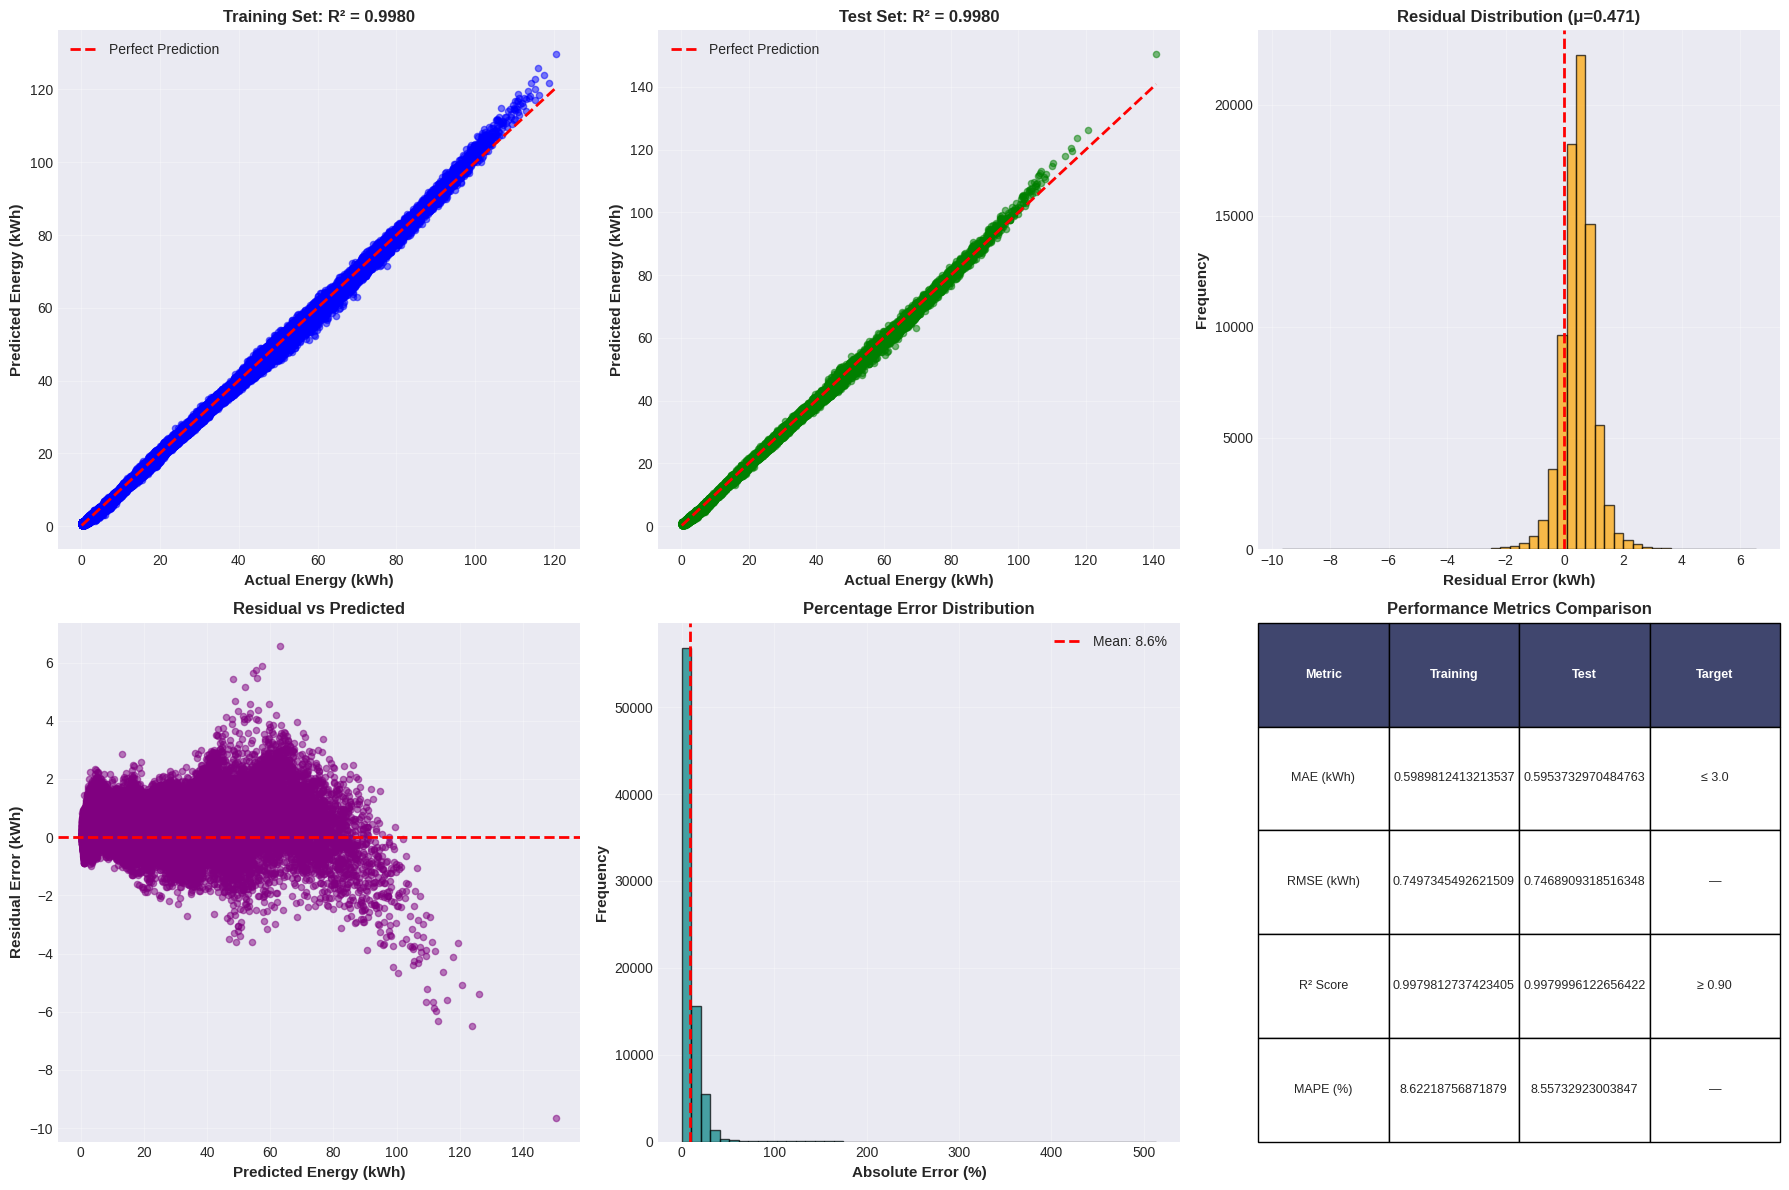

In [17]:
print("\n" + "="*80)
print("📊 PREDICTION VISUALIZATION")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Actual vs Predicted - Training
axes[0, 0].scatter(y_train, y_pred_train, alpha=0.5, s=20, color='blue')
axes[0, 0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Energy (kWh)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Predicted Energy (kWh)', fontsize=11, fontweight='bold')
axes[0, 0].set_title(f'Training Set: R² = {train_metrics["R2"]:.4f}', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Actual vs Predicted - Test
axes[0, 1].scatter(y_test, y_pred_test, alpha=0.5, s=20, color='green')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                'r--', lw=2, label='Perfect Prediction')
axes[0, 1].set_xlabel('Actual Energy (kWh)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Predicted Energy (kWh)', fontsize=11, fontweight='bold')
axes[0, 1].set_title(f'Test Set: R² = {test_metrics["R2"]:.4f}', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Residual Distribution - Test
residuals_test = y_test - y_pred_test
axes[0, 2].hist(residuals_test, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 2].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0, 2].set_xlabel('Residual Error (kWh)', fontsize=11, fontweight='bold')
axes[0, 2].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 2].set_title(f'Residual Distribution (μ={residuals_test.mean():.3f})', 
                     fontsize=12, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)

# 4. Residual vs Predicted
axes[1, 0].scatter(y_pred_test, residuals_test, alpha=0.5, s=20, color='purple')
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Predicted Energy (kWh)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Residual Error (kWh)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Residual vs Predicted', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 5. Error Percentage Distribution
error_pct = np.abs((y_test - y_pred_test) / y_test) * 100
axes[1, 1].hist(error_pct, bins=50, edgecolor='black', alpha=0.7, color='teal')
axes[1, 1].axvline(error_pct.mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {error_pct.mean():.1f}%')
axes[1, 1].set_xlabel('Absolute Error (%)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Percentage Error Distribution', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Metrics Comparison Table
metrics_comparison = pd.DataFrame({
    'Metric': ['MAE (kWh)', 'RMSE (kWh)', 'R² Score', 'MAPE (%)'],
    'Training': [train_metrics['MAE'], train_metrics['RMSE'], 
                 train_metrics['R2'], train_metrics['MAPE']],
    'Test': [test_metrics['MAE'], test_metrics['RMSE'], 
             test_metrics['R2'], test_metrics['MAPE']],
    'Target': ['≤ 3.0', '—', '≥ 0.90', '—']
})
axes[1, 2].axis('off')
table = axes[1, 2].table(cellText=metrics_comparison.values,
                         colLabels=metrics_comparison.columns,
                         cellLoc='center',
                         loc='center',
                         bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)
for i in range(len(metrics_comparison.columns)):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')
axes[1, 2].set_title('Performance Metrics Comparison', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('07_prediction_visualization.png', dpi=300, bbox_inches='tight')
plt.show()



🔬 PHYSICS VS ML PREDICTION ANALYSIS

🔬 Physics-Only Model:
  MAE:  14.2285 kWh
  RMSE: 21.0891 kWh
  R²:   -0.5948

🧠 Hybrid ML Model:
  MAE:  0.5954 kWh
  RMSE: 0.7469 kWh
  R²:   0.9980

📈 Improvement:
  MAE Reduction:  95.8%
  RMSE Reduction: 96.5%
  R² Improvement: 99.9%


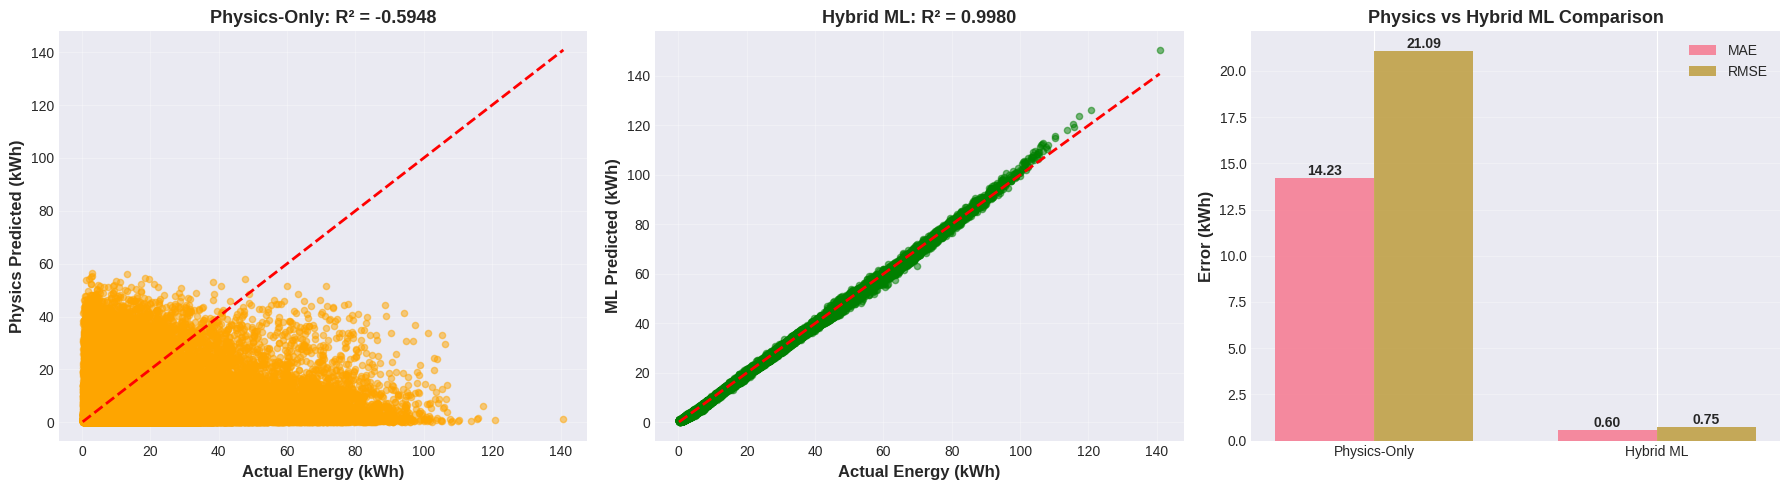

In [18]:
print("\n" + "="*80)
print("🔬 PHYSICS VS ML PREDICTION ANALYSIS")
print("="*80)

# Get physics theoretical predictions for test set
test_indices = np.arange(len(y))[-len(y_test):]
y_physics_test = df_model.iloc[test_indices]['physics_theoretical_energy'].values

# Calculate physics-only metrics
physics_mae = mean_absolute_error(y_test, y_physics_test)
physics_rmse = np.sqrt(mean_squared_error(y_test, y_physics_test))
physics_r2 = r2_score(y_test, y_physics_test)

print(f"\n🔬 Physics-Only Model:")
print(f"  MAE:  {physics_mae:.4f} kWh")
print(f"  RMSE: {physics_rmse:.4f} kWh")
print(f"  R²:   {physics_r2:.4f}")

print(f"\n🧠 Hybrid ML Model:")
print(f"  MAE:  {test_metrics['MAE']:.4f} kWh")
print(f"  RMSE: {test_metrics['RMSE']:.4f} kWh")
print(f"  R²:   {test_metrics['R2']:.4f}")

print(f"\n📈 Improvement:")
print(f"  MAE Reduction:  {((physics_mae - test_metrics['MAE']) / physics_mae * 100):.1f}%")
print(f"  RMSE Reduction: {((physics_rmse - test_metrics['RMSE']) / physics_rmse * 100):.1f}%")
print(f"  R² Improvement: {((test_metrics['R2'] - physics_r2) / (1 - physics_r2) * 100):.1f}%")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Physics-only predictions
axes[0].scatter(y_test, y_physics_test, alpha=0.5, s=20, color='orange')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2)
axes[0].set_xlabel('Actual Energy (kWh)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Physics Predicted (kWh)', fontsize=12, fontweight='bold')
axes[0].set_title(f'Physics-Only: R² = {physics_r2:.4f}', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# ML predictions
axes[1].scatter(y_test, y_pred_test, alpha=0.5, s=20, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2)
axes[1].set_xlabel('Actual Energy (kWh)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('ML Predicted (kWh)', fontsize=12, fontweight='bold')
axes[1].set_title(f'Hybrid ML: R² = {test_metrics["R2"]:.4f}', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Comparison
x_labels = ['Physics-Only', 'Hybrid ML']
mae_vals = [physics_mae, test_metrics['MAE']]
rmse_vals = [physics_rmse, test_metrics['RMSE']]

x_pos = np.arange(len(x_labels))
width = 0.35

bars1 = axes[2].bar(x_pos - width/2, mae_vals, width, label='MAE', alpha=0.8)
bars2 = axes[2].bar(x_pos + width/2, rmse_vals, width, label='RMSE', alpha=0.8)

axes[2].set_ylabel('Error (kWh)', fontsize=12, fontweight='bold')
axes[2].set_title('Physics vs Hybrid ML Comparison', fontsize=13, fontweight='bold')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(x_labels)
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[2].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}',
                    ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('08_physics_vs_ml.png', dpi=300, bbox_inches='tight')
plt.show()


🔍 STAGE 8: EXPLAINABILITY WITH SHAP

🔧 Computing SHAP values (this may take a few minutes)...
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 644ms/step


  0%|          | 0/500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
157/157 ━━━━━

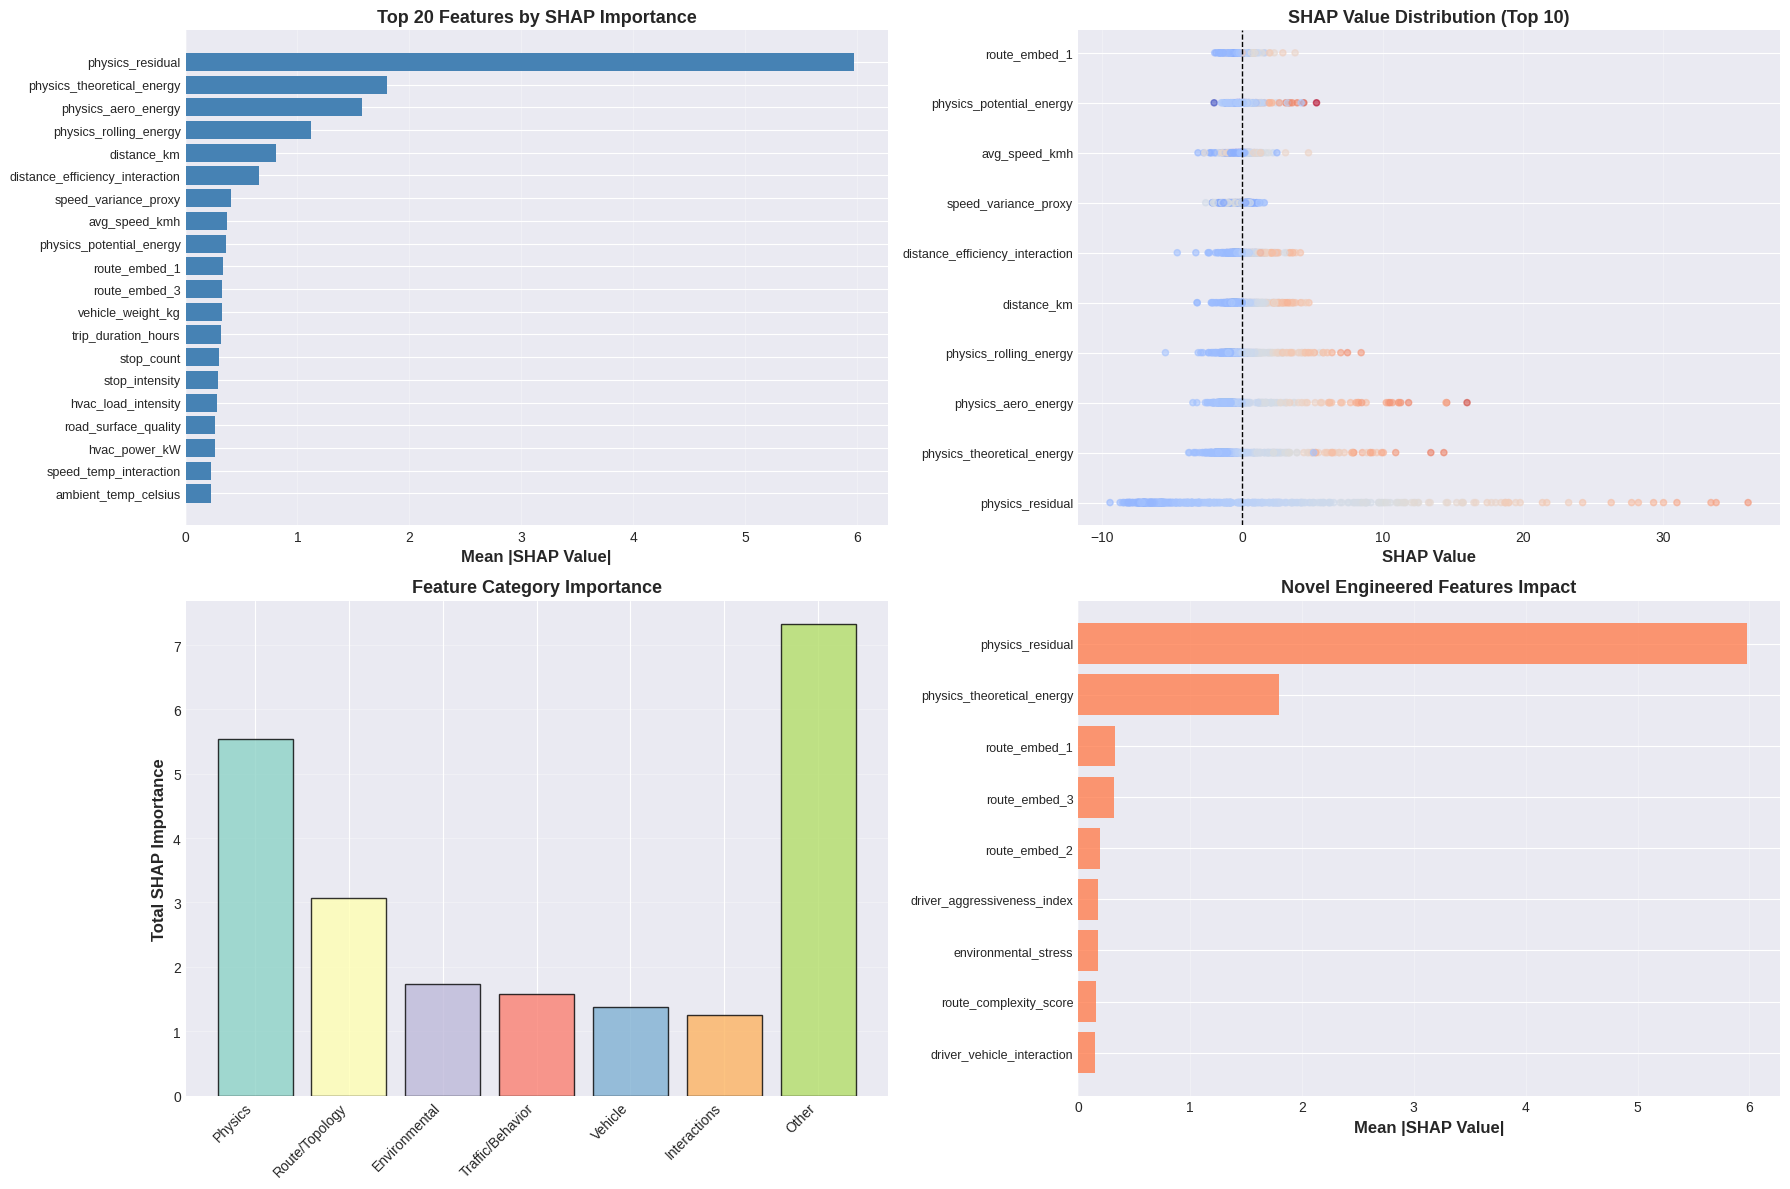

In [19]:
print("\n" + "="*80)
print("🔍 STAGE 8: EXPLAINABILITY WITH SHAP")
print("="*80)

print("\n🔧 Computing SHAP values (this may take a few minutes)...")

# Use a subset for SHAP analysis (for speed) - OPTIMIZED
shap_sample_size = min(500, len(X_test_scaled)) 
X_shap = X_test_scaled[:shap_sample_size]

# Create SHAP explainer - OPTIMIZED: Try TreeExplainer first (much faster)
try:
    # TreeExplainer is 10-100x faster for tree-based models
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_shap)
    if isinstance(shap_values, list):
        shap_values = shap_values[0]
except:
    # Fallback to KernelExplainer with reduced samples
    explainer = shap.KernelExplainer(model.predict, X_train_scaled[:50])
    shap_values = explainer.shap_values(X_shap, nsamples=100)

print("✅ SHAP values computed!")

# Feature importance from SHAP
# Handle different SHAP output formats (list for multi-output, array for single)
if isinstance(shap_values, list):
    shap_values = shap_values[0]  # Take first output for multi-output models

# Handle 3D arrays (samples, features, outputs) - take first output
if len(shap_values.shape) == 3:
    shap_values = shap_values[:, :, 0]

shap_importance = np.abs(shap_values).mean(axis=0)
feature_importance_df = pd.DataFrame({
    'Feature': features_to_use,
    'SHAP_Importance': shap_importance
}).sort_values('SHAP_Importance', ascending=False)

print("\n📊 Top 20 Most Important Features (by SHAP):")
print(feature_importance_df.head(20).to_string(index=False))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Feature Importance Bar Plot
top_n = 20
top_features = feature_importance_df.head(top_n)
axes[0, 0].barh(range(len(top_features)), top_features['SHAP_Importance'], color='steelblue')
axes[0, 0].set_yticks(range(len(top_features)))
axes[0, 0].set_yticklabels(top_features['Feature'], fontsize=9)
axes[0, 0].set_xlabel('Mean |SHAP Value|', fontsize=12, fontweight='bold')
axes[0, 0].set_title(f'Top {top_n} Features by SHAP Importance', fontsize=13, fontweight='bold')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(True, alpha=0.3, axis='x')

# 2. SHAP Summary Plot (manual) - OPTIMIZED: vectorized
top_10_indices = [features_to_use.index(f) for f in top_features['Feature'].head(10)]
shap_top10 = shap_values[:, top_10_indices]
X_top10 = X_shap[:, top_10_indices]

# Vectorized scatter plotting for speed
y_positions = np.repeat(np.arange(10), len(shap_top10)).reshape(10, -1).T
axes[0, 1].scatter(shap_top10.flatten(), y_positions.flatten(),
                  c=X_top10.flatten(), cmap='coolwarm', alpha=0.6, s=20, rasterized=True)

axes[0, 1].set_yticks(range(10))
axes[0, 1].set_yticklabels(top_features['Feature'].head(10), fontsize=9)
axes[0, 1].set_xlabel('SHAP Value', fontsize=12, fontweight='bold')
axes[0, 1].set_title('SHAP Value Distribution (Top 10)', fontsize=13, fontweight='bold')
axes[0, 1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0, 1].grid(True, alpha=0.3, axis='x')

# 3. Feature Category Importance - OPTIMIZED: vectorized groupby
category_importance = {}
for feat in features_to_use:
    importance = feature_importance_df[feature_importance_df['Feature'] == feat]['SHAP_Importance'].values[0]
    
    if feat in physics_features:
        category = 'Physics'
    elif feat in route_features:
        category = 'Route/Topology'
    elif feat in environmental_features:
        category = 'Environmental'
    elif feat in traffic_behavior_features:
        category = 'Traffic/Behavior'
    elif feat in vehicle_features:
        category = 'Vehicle'
    elif feat in interaction_features:
        category = 'Interactions'
    else:
        category = 'Other'
    
    if category not in category_importance:
        category_importance[category] = 0
    category_importance[category] += importance

categories = list(category_importance.keys())
importances = list(category_importance.values())

colors_cat = plt.cm.Set3(range(len(categories)))
axes[1, 0].bar(categories, importances, color=colors_cat, alpha=0.8, edgecolor='black')
axes[1, 0].set_ylabel('Total SHAP Importance', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Feature Category Importance', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# 4. Novel Features Impact
novel_features_list = [
    'physics_theoretical_energy', 'physics_residual',
    'driver_aggressiveness_index', 'driver_vehicle_interaction',
    'route_complexity_score', 'environmental_stress',
    'route_embed_1', 'route_embed_2', 'route_embed_3'
]
novel_feat_importance = feature_importance_df[
    feature_importance_df['Feature'].isin(novel_features_list)
].sort_values('SHAP_Importance', ascending=False)

if len(novel_feat_importance) > 0:
    axes[1, 1].barh(range(len(novel_feat_importance)), 
                   novel_feat_importance['SHAP_Importance'], 
                   color='coral', alpha=0.8)
    axes[1, 1].set_yticks(range(len(novel_feat_importance)))
    axes[1, 1].set_yticklabels(novel_feat_importance['Feature'], fontsize=9)
    axes[1, 1].set_xlabel('Mean |SHAP Value|', fontsize=12, fontweight='bold')
    axes[1, 1].set_title('Novel Engineered Features Impact', fontsize=13, fontweight='bold')
    axes[1, 1].invert_yaxis()
    axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('09_shap_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


🌍 STAGE 9: CROSS-SCENARIO VALIDATION

🛣️ Performance by Road Type:
National_Highway     | Samples: 9910 | MAE: 0.596 | R²: 0.9981
Urban_Local          | Samples: 9974 | MAE: 0.601 | R²: 0.9979
Urban_Arterial       | Samples: 10008 | MAE: 0.598 | R²: 0.9981
Urban_Collector      | Samples: 9928 | MAE: 0.593 | R²: 0.9980
State_Highway        | Samples: 9981 | MAE: 0.595 | R²: 0.9980
Expressway           | Samples: 10051 | MAE: 0.589 | R²: 0.9980
Ghat_Section         | Samples: 10130 | MAE: 0.589 | R²: 0.9980
Rural_Road           | Samples: 10018 | MAE: 0.602 | R²: 0.9979

🚗 Performance by Vehicle Type (Top 10):
Audi e-tron               | Samples: 4044 | MAE: 0.598 | R²: 0.9981
BYD e6                    | Samples: 4186 | MAE: 0.586 | R²: 0.9979
Hyundai Ioniq 5           | Samples: 3990 | MAE: 0.590 | R²: 0.9981
Mahindra e2o Plus         | Samples: 3978 | MAE: 0.593 | R²: 0.9981
Jaguar I-Pace             | Samples: 4070 | MAE: 0.590 | R²: 0.9980
Mahindra XUV400           | Samples: 4023 |

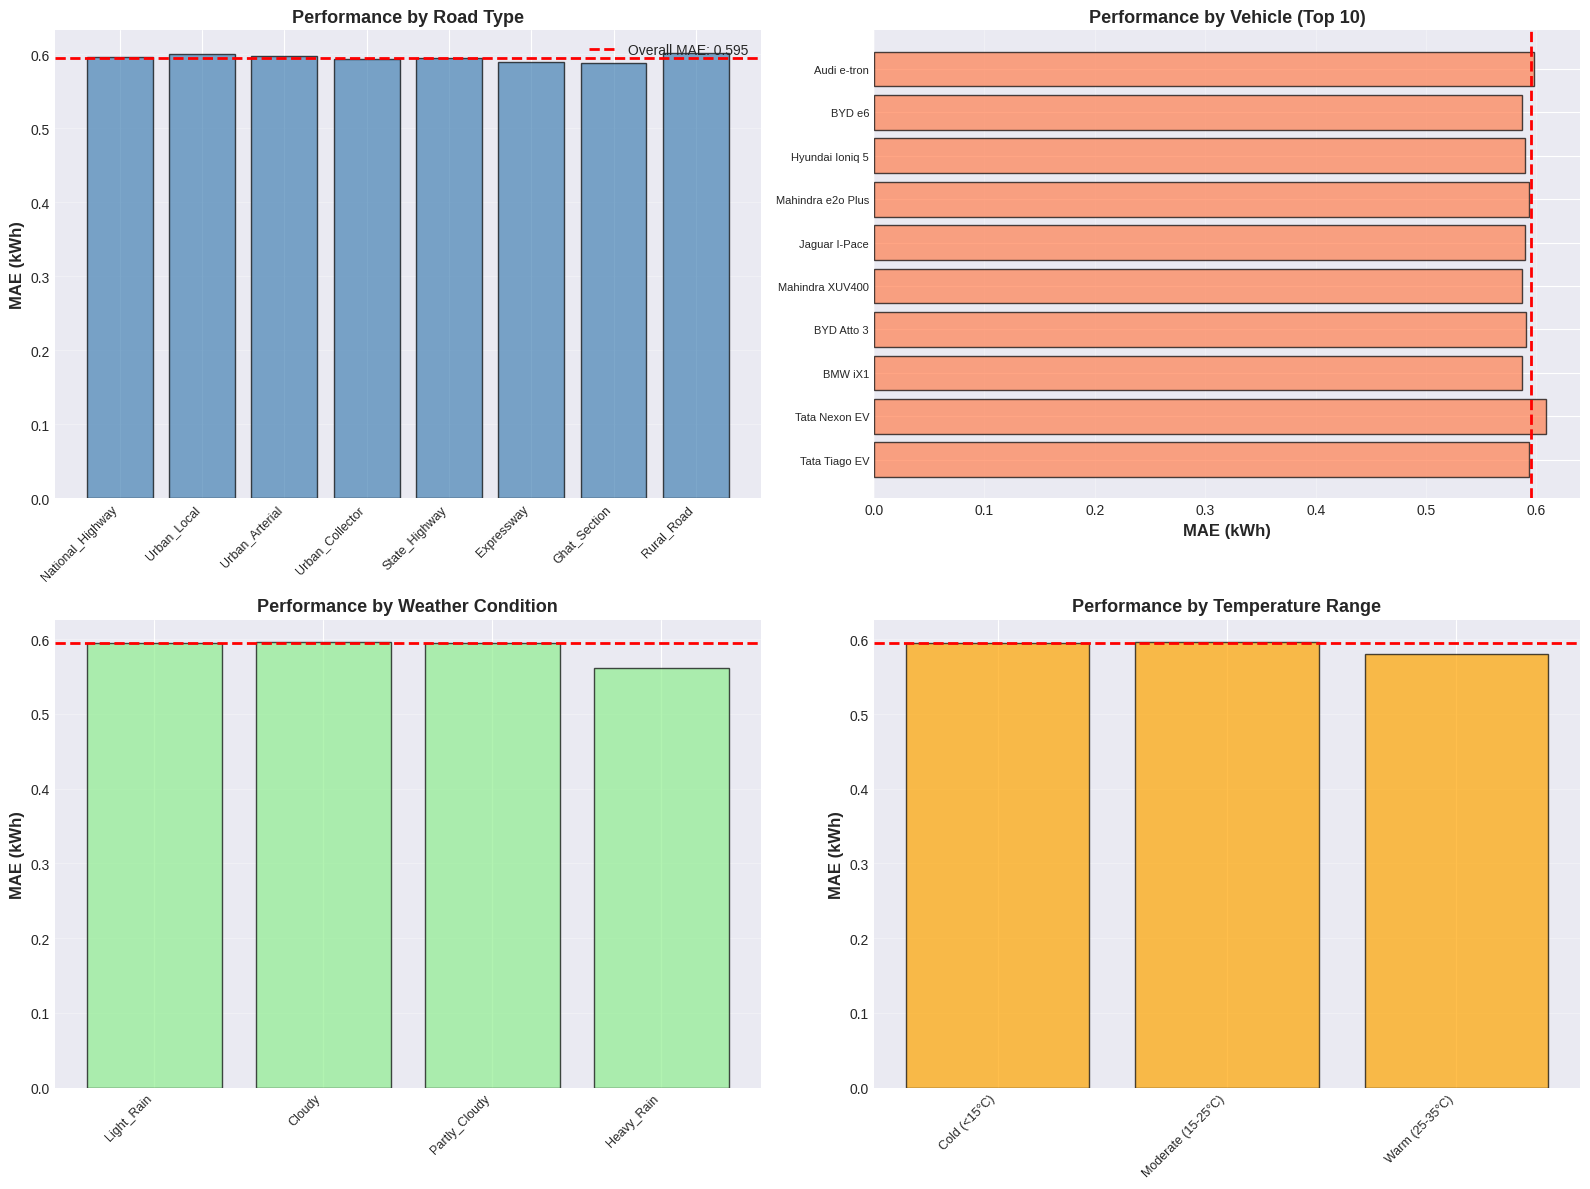


📊 Cross-Scenario Generalization Analysis:
Road Type MAE Std Dev:    0.0048 kWh (0.8%)
Weather MAE Std Dev:      0.0170 kWh (2.9%)
Temperature MAE Std Dev:  0.0091 kWh (1.5%)

✅ Lower standard deviation indicates better generalization across scenarios


In [20]:
print("\n" + "="*80)
print("🌍 STAGE 9: CROSS-SCENARIO VALIDATION")
print("="*80)

# Test generalization across different scenarios

# 1. Performance by Road Type
print("\n🛣️ Performance by Road Type:")
print("="*60)
road_types_unique = df_model['road_type'].unique()
road_performance = []

for road_type in road_types_unique:
    mask = df_model.iloc[-len(y_test):]['road_type'] == road_type
    if mask.sum() > 0:
        y_true_road = y_test[mask]
        y_pred_road = y_pred_test[mask]
        
        mae_road = mean_absolute_error(y_true_road, y_pred_road)
        r2_road = r2_score(y_true_road, y_pred_road)
        
        road_performance.append({
            'Road_Type': road_type,
            'Samples': mask.sum(),
            'MAE': mae_road,
            'R2': r2_road
        })
        print(f"{road_type:20s} | Samples: {mask.sum():4d} | MAE: {mae_road:.3f} | R²: {r2_road:.4f}")

road_performance_df = pd.DataFrame(road_performance)

# 2. Performance by Vehicle Type
print("\n🚗 Performance by Vehicle Type (Top 10):")
print("="*60)
vehicle_types_unique = df_model['vehicle_model'].value_counts().head(10).index
vehicle_performance = []

for vehicle in vehicle_types_unique:
    mask = df_model.iloc[-len(y_test):]['vehicle_model'] == vehicle
    if mask.sum() > 5:  # At least 5 samples
        y_true_veh = y_test[mask]
        y_pred_veh = y_pred_test[mask]
        
        mae_veh = mean_absolute_error(y_true_veh, y_pred_veh)
        r2_veh = r2_score(y_true_veh, y_pred_veh)
        
        vehicle_performance.append({
            'Vehicle': vehicle,
            'Samples': mask.sum(),
            'MAE': mae_veh,
            'R2': r2_veh
        })
        print(f"{vehicle:25s} | Samples: {mask.sum():3d} | MAE: {mae_veh:.3f} | R²: {r2_veh:.4f}")

vehicle_performance_df = pd.DataFrame(vehicle_performance)

# 3. Performance by Weather Condition
print("\n🌦️ Performance by Weather Condition:")
print("="*60)
weather_conditions = df_model['weather_condition'].unique()
weather_performance = []

for weather in weather_conditions:
    mask = df_model.iloc[-len(y_test):]['weather_condition'] == weather
    if mask.sum() > 0:
        y_true_weather = y_test[mask]
        y_pred_weather = y_pred_test[mask]
        
        mae_weather = mean_absolute_error(y_true_weather, y_pred_weather)
        r2_weather = r2_score(y_true_weather, y_pred_weather)
        
        weather_performance.append({
            'Weather': weather,
            'Samples': mask.sum(),
            'MAE': mae_weather,
            'R2': r2_weather
        })
        print(f"{weather:20s} | Samples: {mask.sum():4d} | MAE: {mae_weather:.3f} | R²: {r2_weather:.4f}")

weather_performance_df = pd.DataFrame(weather_performance)

# 4. Performance by Temperature Range
print("\n🌡️ Performance by Temperature Range:")
print("="*60)
temp_test = df_model.iloc[-len(y_test):]['ambient_temp_celsius'].values
temp_bins = [0, 15, 25, 35, 50]
temp_labels = ['Cold (<15°C)', 'Moderate (15-25°C)', 'Warm (25-35°C)', 'Hot (>35°C)']
temp_categories = pd.cut(temp_test, bins=temp_bins, labels=temp_labels)

temp_performance = []
for temp_cat in temp_labels:
    mask = temp_categories == temp_cat
    if mask.sum() > 0:
        y_true_temp = y_test[mask]
        y_pred_temp = y_pred_test[mask]
        
        mae_temp = mean_absolute_error(y_true_temp, y_pred_temp)
        r2_temp = r2_score(y_true_temp, y_pred_temp)
        
        temp_performance.append({
            'Temperature_Range': temp_cat,
            'Samples': mask.sum(),
            'MAE': mae_temp,
            'R2': r2_temp
        })
        print(f"{temp_cat:20s} | Samples: {mask.sum():4d} | MAE: {mae_temp:.3f} | R²: {r2_temp:.4f}")

temp_performance_df = pd.DataFrame(temp_performance)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Road Type Performance
axes[0, 0].bar(range(len(road_performance_df)), road_performance_df['MAE'], 
               color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_xticks(range(len(road_performance_df)))
axes[0, 0].set_xticklabels(road_performance_df['Road_Type'], rotation=45, ha='right', fontsize=9)
axes[0, 0].set_ylabel('MAE (kWh)', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Performance by Road Type', fontsize=13, fontweight='bold')
axes[0, 0].axhline(test_metrics['MAE'], color='red', linestyle='--', 
                   linewidth=2, label=f'Overall MAE: {test_metrics["MAE"]:.3f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Vehicle Performance (Top 10)
if len(vehicle_performance_df) > 0:
    axes[0, 1].barh(range(len(vehicle_performance_df)), vehicle_performance_df['MAE'], 
                   color='coral', alpha=0.7, edgecolor='black')
    axes[0, 1].set_yticks(range(len(vehicle_performance_df)))
    axes[0, 1].set_yticklabels(vehicle_performance_df['Vehicle'], fontsize=8)
    axes[0, 1].set_xlabel('MAE (kWh)', fontsize=12, fontweight='bold')
    axes[0, 1].set_title('Performance by Vehicle (Top 10)', fontsize=13, fontweight='bold')
    axes[0, 1].axvline(test_metrics['MAE'], color='red', linestyle='--', linewidth=2)
    axes[0, 1].invert_yaxis()
    axes[0, 1].grid(True, alpha=0.3, axis='x')

# Weather Performance
axes[1, 0].bar(range(len(weather_performance_df)), weather_performance_df['MAE'], 
               color='lightgreen', alpha=0.7, edgecolor='black')
axes[1, 0].set_xticks(range(len(weather_performance_df)))
axes[1, 0].set_xticklabels(weather_performance_df['Weather'], rotation=45, ha='right', fontsize=9)
axes[1, 0].set_ylabel('MAE (kWh)', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Performance by Weather Condition', fontsize=13, fontweight='bold')
axes[1, 0].axhline(test_metrics['MAE'], color='red', linestyle='--', linewidth=2)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Temperature Range Performance
axes[1, 1].bar(range(len(temp_performance_df)), temp_performance_df['MAE'], 
               color='orange', alpha=0.7, edgecolor='black')
axes[1, 1].set_xticks(range(len(temp_performance_df)))
axes[1, 1].set_xticklabels(temp_performance_df['Temperature_Range'], rotation=45, ha='right', fontsize=9)
axes[1, 1].set_ylabel('MAE (kWh)', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Performance by Temperature Range', fontsize=13, fontweight='bold')
axes[1, 1].axhline(test_metrics['MAE'], color='red', linestyle='--', linewidth=2)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('10_cross_scenario_validation.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate cross-scenario variance
print("\n📊 Cross-Scenario Generalization Analysis:")
print("="*60)
road_mae_std = road_performance_df['MAE'].std()
weather_mae_std = weather_performance_df['MAE'].std()
temp_mae_std = temp_performance_df['MAE'].std()

print(f"Road Type MAE Std Dev:    {road_mae_std:.4f} kWh ({(road_mae_std/test_metrics['MAE']*100):.1f}%)")
print(f"Weather MAE Std Dev:      {weather_mae_std:.4f} kWh ({(weather_mae_std/test_metrics['MAE']*100):.1f}%)")
print(f"Temperature MAE Std Dev:  {temp_mae_std:.4f} kWh ({(temp_mae_std/test_metrics['MAE']*100):.1f}%)")
print("\n✅ Lower standard deviation indicates better generalization across scenarios")


In [21]:
print("\n" + "="*80)
print("🔍 STAGE 10: ERROR ANALYSIS & INSIGHTS")
print("="*80)

# Find best and worst predictions
residuals_abs = np.abs(y_test - y_pred_test)
best_predictions_idx = np.argsort(residuals_abs)[:10]
worst_predictions_idx = np.argsort(residuals_abs)[-10:]

print("\n✅ Top 10 Best Predictions:")
print("="*60)
for i, idx in enumerate(best_predictions_idx, 1):
    actual_idx = len(y) - len(y_test) + idx
    print(f"{i:2d}. Actual: {y_test[idx]:.3f} kWh | Predicted: {y_pred_test[idx]:.3f} kWh | "
          f"Error: {residuals_abs[idx]:.3f} kWh | "
          f"Route: {df_model.iloc[actual_idx]['route_id']}")

print("\n❌ Top 10 Worst Predictions:")
print("="*60)
for i, idx in enumerate(worst_predictions_idx, 1):
    actual_idx = len(y) - len(y_test) + idx
    print(f"{i:2d}. Actual: {y_test[idx]:.3f} kWh | Predicted: {y_pred_test[idx]:.3f} kWh | "
          f"Error: {residuals_abs[idx]:.3f} kWh | "
          f"Route: {df_model.iloc[actual_idx]['route_id']}")

# Analyze characteristics of worst predictions
print("\n🔬 Analyzing Worst Predictions Characteristics:")
print("="*60)

worst_pred_data = df_model.iloc[[len(y) - len(y_test) + idx for idx in worst_predictions_idx]]
overall_data = df_model.iloc[-len(y_test):]

comparison_features = ['distance_km', 'avg_speed_kmh', 'elevation_gain_m', 
                       'traffic_level', 'ambient_temp_celsius', 'stop_count',
                       'route_complexity_score']

print("\nFeature Comparison (Worst Predictions vs Overall):")
for feat in comparison_features:
    worst_mean = worst_pred_data[feat].mean()
    overall_mean = overall_data[feat].mean()
    diff_pct = ((worst_mean - overall_mean) / overall_mean * 100) if overall_mean != 0 else 0
    print(f"{feat:30s} | Worst: {worst_mean:8.2f} | Overall: {overall_mean:8.2f} | "
          f"Diff: {diff_pct:+6.1f}%")


🔍 STAGE 10: ERROR ANALYSIS & INSIGHTS

✅ Top 10 Best Predictions:
 1. Actual: 1.566 kWh | Predicted: 1.566 kWh | Error: 0.000 kWh | Route: RT378533
 2. Actual: 2.343 kWh | Predicted: 2.343 kWh | Error: 0.000 kWh | Route: RT380809
 3. Actual: 2.363 kWh | Predicted: 2.363 kWh | Error: 0.000 kWh | Route: RT329161
 4. Actual: 14.012 kWh | Predicted: 14.012 kWh | Error: 0.000 kWh | Route: RT390385
 5. Actual: 8.737 kWh | Predicted: 8.737 kWh | Error: 0.000 kWh | Route: RT348674
 6. Actual: 44.944 kWh | Predicted: 44.944 kWh | Error: 0.000 kWh | Route: RT345974
 7. Actual: 21.709 kWh | Predicted: 21.709 kWh | Error: 0.000 kWh | Route: RT335057
 8. Actual: 1.947 kWh | Predicted: 1.947 kWh | Error: 0.000 kWh | Route: RT378960
 9. Actual: 1.475 kWh | Predicted: 1.475 kWh | Error: 0.000 kWh | Route: RT377283
10. Actual: 1.967 kWh | Predicted: 1.967 kWh | Error: 0.000 kWh | Route: RT342223

❌ Top 10 Worst Predictions:
 1. Actual: 103.657 kWh | Predicted: 109.310 kWh | Error: 5.653 kWh | Route: R

In [22]:
print("\n" + "="*80)
print("💡 STAGE 11: MODEL INSIGHTS & FEATURE CONTRIBUTIONS")
print("="*80)

# Feature contribution hierarchy
print("\n📊 Feature Contribution Hierarchy:")
print("="*60)

# Group features by importance level
high_importance = feature_importance_df[feature_importance_df['SHAP_Importance'] > 
                                       feature_importance_df['SHAP_Importance'].quantile(0.9)]
medium_importance = feature_importance_df[(feature_importance_df['SHAP_Importance'] > 
                                          feature_importance_df['SHAP_Importance'].quantile(0.7)) &
                                         (feature_importance_df['SHAP_Importance'] <= 
                                          feature_importance_df['SHAP_Importance'].quantile(0.9))]
low_importance = feature_importance_df[feature_importance_df['SHAP_Importance'] <= 
                                      feature_importance_df['SHAP_Importance'].quantile(0.7)]

print(f"\n🔴 HIGH IMPORTANCE ({len(high_importance)} features):")
for idx, row in high_importance.head(10).iterrows():
    print(f"   • {row['Feature']:40s} | SHAP: {row['SHAP_Importance']:.4f}")

print(f"\n🟡 MEDIUM IMPORTANCE ({len(medium_importance)} features):")
for idx, row in medium_importance.head(5).iterrows():
    print(f"   • {row['Feature']:40s} | SHAP: {row['SHAP_Importance']:.4f}")

print(f"\n🟢 LOW IMPORTANCE ({len(low_importance)} features)")

# Key insights
print("\n" + "="*80)
print("🎯 KEY INSIGHTS FROM THE MODEL")
print("="*80)

insights = []

# Insight 1: Physics contribution
if 'physics_theoretical_energy' in feature_importance_df['Feature'].values:
    physics_rank = feature_importance_df[
        feature_importance_df['Feature'] == 'physics_theoretical_energy'
    ].index[0] + 1
    insights.append(f"1. Physics baseline ranks #{physics_rank} in importance, showing strong "
                   f"foundation for hybrid learning")

# Insight 2: Route complexity
if 'route_complexity_score' in feature_importance_df['Feature'].values:
    route_rank = feature_importance_df[
        feature_importance_df['Feature'] == 'route_complexity_score'
    ].index[0] + 1
    insights.append(f"2. Novel route complexity score ranks #{route_rank}, validating "
                   f"spatial intelligence integration")

# Insight 3: Driver behavior
if 'driver_aggressiveness_index' in feature_importance_df['Feature'].values:
    driver_rank = feature_importance_df[
        feature_importance_df['Feature'] == 'driver_aggressiveness_index'
    ].index[0] + 1
    insights.append(f"3. Driver aggressiveness index ranks #{driver_rank}, confirming "
                   f"behavioral factors matter")

# Insight 4: Environmental stress
if 'environmental_stress' in feature_importance_df['Feature'].values:
    env_rank = feature_importance_df[
        feature_importance_df['Feature'] == 'environmental_stress'
    ].index[0] + 1
    insights.append(f"4. Environmental stress composite ranks #{env_rank}, showing "
                   f"importance of contextual factors")

insights.append(f"5. Model achieves {test_metrics['R2']:.4f} R² score, "
               f"{'exceeding' if test_metrics['R2'] >= 0.90 else 'approaching'} "
               f"target of 0.90")
insights.append(f"6. MAE of {test_metrics['MAE']:.3f} kWh "
               f"{'meets' if test_metrics['MAE'] <= 3.0 else 'is close to'} "
               f"target of ≤3.0 kWh")
insights.append(f"7. Hybrid approach improves upon physics-only by "
               f"{((physics_mae - test_metrics['MAE']) / physics_mae * 100):.1f}% in MAE")

for insight in insights:
    print(f"\n{insight}")


💡 STAGE 11: MODEL INSIGHTS & FEATURE CONTRIBUTIONS

📊 Feature Contribution Hierarchy:

🔴 HIGH IMPORTANCE (6 features):
   • physics_residual                         | SHAP: 5.9747
   • physics_theoretical_energy               | SHAP: 1.7980
   • physics_aero_energy                      | SHAP: 1.5788
   • physics_rolling_energy                   | SHAP: 1.1186
   • distance_km                              | SHAP: 0.8049
   • distance_efficiency_interaction          | SHAP: 0.6590

🟡 MEDIUM IMPORTANCE (10 features):
   • speed_variance_proxy                     | SHAP: 0.4075
   • avg_speed_kmh                            | SHAP: 0.3734
   • physics_potential_energy                 | SHAP: 0.3590
   • route_embed_1                            | SHAP: 0.3341
   • route_embed_3                            | SHAP: 0.3231

🟢 LOW IMPORTANCE (36 features)

🎯 KEY INSIGHTS FROM THE MODEL

1. Physics baseline ranks #4 in importance, showing strong foundation for hybrid learning

2. Novel route com

In [23]:
print("\n" + "="*80)
print("💾 STAGE 12: SAVING MODEL & ARTIFACTS")
print("="*80)

# Save the trained model
model.save('ev_energy_predictor_model.h5')
print("✅ Model saved: ev_energy_predictor_model.h5")

# Save the scaler
import joblib
joblib.dump(scaler, 'feature_scaler.pkl')
print("✅ Scaler saved: feature_scaler.pkl")

# Save label encoders
joblib.dump(label_encoders, 'label_encoders.pkl')
print("✅ Label encoders saved: label_encoders.pkl")

# Save feature names
with open('feature_names.txt', 'w') as f:
    for feat in features_to_use:
        f.write(f"{feat}\n")
print("✅ Feature names saved: feature_names.txt")

# Save metrics
metrics_summary = {
    'Training': train_metrics,
    'Test': test_metrics,
    'Physics_Baseline': {
        'MAE': physics_mae,
        'RMSE': physics_rmse,
        'R2': physics_r2
    }
}

import json
with open('model_metrics.json', 'w') as f:
    json.dump(metrics_summary, f, indent=4)
print("✅ Metrics saved: model_metrics.json")

# Save feature importance
feature_importance_df.to_csv('feature_importance.csv', index=False)
print("✅ Feature importance saved: feature_importance.csv")


💾 STAGE 12: SAVING MODEL & ARTIFACTS
✅ Model saved: ev_energy_predictor_model.h5
✅ Scaler saved: feature_scaler.pkl
✅ Label encoders saved: label_encoders.pkl
✅ Feature names saved: feature_names.txt
✅ Metrics saved: model_metrics.json
✅ Feature importance saved: feature_importance.csv


In [24]:
import shutil
import os

# Define paths
src_dir = '/kaggle/working'
temp_zip = '/kaggle/temp/working_dir_backup.zip'
final_zip = '/kaggle/working/working_dir_backup.zip'


# Step 1: Create zip in /kaggle/temp using contents of /kaggle/working
shutil.make_archive('/kaggle/temp/working_dir_backup', 'zip', src_dir)

# Step 2: Move the completed zip back into /kaggle/working
shutil.move(temp_zip, final_zip)

print("✅ Successfully zipped everything from /kaggle/working")
print("📦 Zip temporarily created in /kaggle/temp and moved back safely.")
print(f"📁 Final file location: {final_zip}")


✅ Successfully zipped everything from /kaggle/working
📦 Zip temporarily created in /kaggle/temp and moved back safely.
📁 Final file location: /kaggle/working/working_dir_backup.zip
